# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding** 

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [170]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')


### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [90]:
# Load the dataset
df = pd.read_csv("health_data.csv")

#### **1.1.1** Check the first few entries

In [91]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [92]:
# Remove irrelevant columns like unique identifiers or index
df.drop(['Unnamed: 0', 'id'], inplace=True, axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.3** Inspect the shape of the dataset

In [93]:
# Inspect the shape of the dataset
df.shape

(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [94]:
# Inspect the different columns in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


Check the summary of the dataset

In [95]:
# Check the summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,0.349571,0.476838,0.0,0.0,0.0,1.0,1.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,0.366871,0.680250,0.0,0.0,0.0,1.0,2.0
gluc,70000.0,0.226457,0.572270,0.0,0.0,0.0,0.0,2.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


## **2. Data Cleaning** 

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values** 

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [96]:
# Check the statistical summary of the data
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,0.349571,0.476838,0.0,0.0,0.0,1.0,1.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,0.366871,0.680250,0.0,0.0,0.0,1.0,2.0
gluc,70000.0,0.226457,0.572270,0.0,0.0,0.0,0.0,2.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


There are some outliers based on the output of the above cell: 
1. Height of 250 seems to be outlier. I think we need to filter out the entries which are more than 170cm + IQR as outlier.
2. Similarly ap_hi and ap_lo are showing clear outliers for Blood pressure going beyod 140 + IQR and 90 + IQR.


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

- Systolic (ap_hi): between ~30 and 300 (assignment‑specified range)
- Diastolic (ap_lo): between ~30 and 300 (same)
- Logical BP check: ap_hi > ap_lo (systolic must exceed diastolic)
- Height: between ~120 cm and ~220 cm (adult range)
- Weight: between ~30 kg and ~200 kg (adult range)

In [97]:
print("=== Rows with invalid/illogical physiological values ===")
print(f"ap_hi < 30 or ap_hi > 300  : {((df['ap_hi'] < 30) | (df['ap_hi'] > 300)).sum()}")
print(f"ap_lo < 30 or ap_lo > 300  : {((df['ap_lo'] < 30) | (df['ap_lo'] > 300)).sum()}")
print(f"ap_lo >= ap_hi (illogical) : {(df['ap_lo'] >= df['ap_hi']).sum()}")
print(f"height < 120 or height > 220: {((df['height'] < 120) | (df['height'] > 220)).sum()}")
print(f"weight < 30 or weight > 200 : {((df['weight'] < 30) | (df['weight'] > 200)).sum()}")
print(f"\nTotal rows before cleaning : {df.shape[0]}")


=== Rows with invalid/illogical physiological values ===
ap_hi < 30 or ap_hi > 300  : 228
ap_lo < 30 or ap_lo > 300  : 1006
ap_lo >= ap_hi (illogical) : 1236
height < 120 or height > 220: 53
weight < 30 or weight > 200 : 7

Total rows before cleaning : 70000


In [98]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc
valid_mask = (
    (df['ap_hi'] >= 30) & (df['ap_hi'] <= 300) &
    (df['ap_lo'] >= 30) & (df['ap_lo'] <= 300) &
    (df['ap_hi'] > df['ap_lo']) &
    (df['height'] >= 120) & (df['height'] <= 220) &
    (df['weight'] >= 30) & (df['weight'] <= 200)
)
# Drop invalid rows
df = df[valid_mask].reset_index(drop=True)

print(f"Total rows after cleaning  : {df.shape[0]}")
print(f"Rows removed               : {70000 - df.shape[0]} ({(70000 - df.shape[0])/70000*100:.2f}%)")

Total rows after cleaning  : 68622
Rows removed               : 1378 (1.97%)


In [99]:

# Confirm the ranges look sensible now
df[['ap_hi', 'ap_lo', 'height', 'weight']].describe().T

,count,mean,std,min,25%,50%,75%,max
ap_hi,68622.0,126.675862,16.692264,60.0,120.0,120.0,140.0,240.0
ap_lo,68622.0,81.303270,9.464607,30.0,80.0,80.0,90.0,182.0
height,68622.0,164.413439,7.912540,120.0,159.0,165.0,170.0,207.0
weight,68622.0,74.115705,14.295676,30.0,65.0,72.0,82.0,200.0


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

- Age is stored in days currently, which needs to be converted to years. For that purpose divide the # of days by 365.25.
- Also the height is stored in the cms, will convert them to meters. For that we will divide the height by 100.

In [100]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
# Convert age from days to years (rounded to 1 decimal for readability)
df['age'] = (df['age'] / 365.25).round(1)
# Convert height from centimeters to meters
df['height'] = (df['height'] / 100).round(2)
# Verify the conversions
print("Age (years) - min:", df['age'].min(), "| max:", df['age'].max())
print("Height (m)  - min:", df['height'].min(), "| max:", df['height'].max())
df[['age', 'height']].describe().T


Age (years) - min: 29.6 | max: 64.9
Height (m)  - min: 1.2 | max: 2.07


,count,mean,std,min,25%,50%,75%,max
age,68622.0,53.291783,6.757068,29.6,48.30,53.90,58.4,64.90
height,68622.0,1.644134,0.079125,1.2,1.59,1.65,1.7,2.07


### **2.2 Fix DataTypes** 

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data 

##### From the data dictionary:
- age is continuous (in days, needs conversion to years)
- gender is categorical with values 1 for Female and 2 for Male
- height and weight are continuous
- ap_hi and ap_lo are continuous blood pressure readings
- cholesterol and gluc are ordinal categorical variables (originally 1/2/3, cleaned to 0/1/2)
- smoke, alco, active, and cardio are all binary categorical variables (0/1)

In [101]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
# Convert them to 'category' dtype
df[categorical_cols] = df[categorical_cols].astype('category')


In [102]:
# Check the final data types post conversion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68622 entries, 0 to 68621
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68622 non-null  float64 
 1   gender       68622 non-null  category
 2   height       68622 non-null  float64 
 3   weight       68622 non-null  float64 
 4   ap_hi        68622 non-null  float64 
 5   ap_lo        68622 non-null  float64 
 6   cholesterol  68622 non-null  category
 7   gluc         68622 non-null  category
 8   smoke        68622 non-null  category
 9   alco         68622 non-null  category
 10  active       68622 non-null  category
 11  cardio       68622 non-null  category
dtypes: category(7), float64(5)
memory usage: 3.1 MB


- select_dtypes(include='category') and select_dtypes(include='number') will now correctly separate columns for different plot types automatically.
- Dummy variables : pd.get_dummies() uses dtype to decide which columns to encode — having the right dtype prevents accidentally one-hot encoding numerical columns.
- Feature scaling select_dtypes(include='number') will correctly pick only age, height, weight, ap_hi, ap_lo for scaling — categorical columns won't be touched.

In [103]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.4,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0
1,55.4,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1
2,51.6,0,1.65,64.0,130.0,70.0,2,0,0,0,0,1
3,48.2,1,1.69,82.0,150.0,100.0,0,0,0,0,1,1
4,47.8,0,1.56,56.0,100.0,60.0,0,0,0,0,0,0


## **3. Exploratory Data Analysis** 

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis** 

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

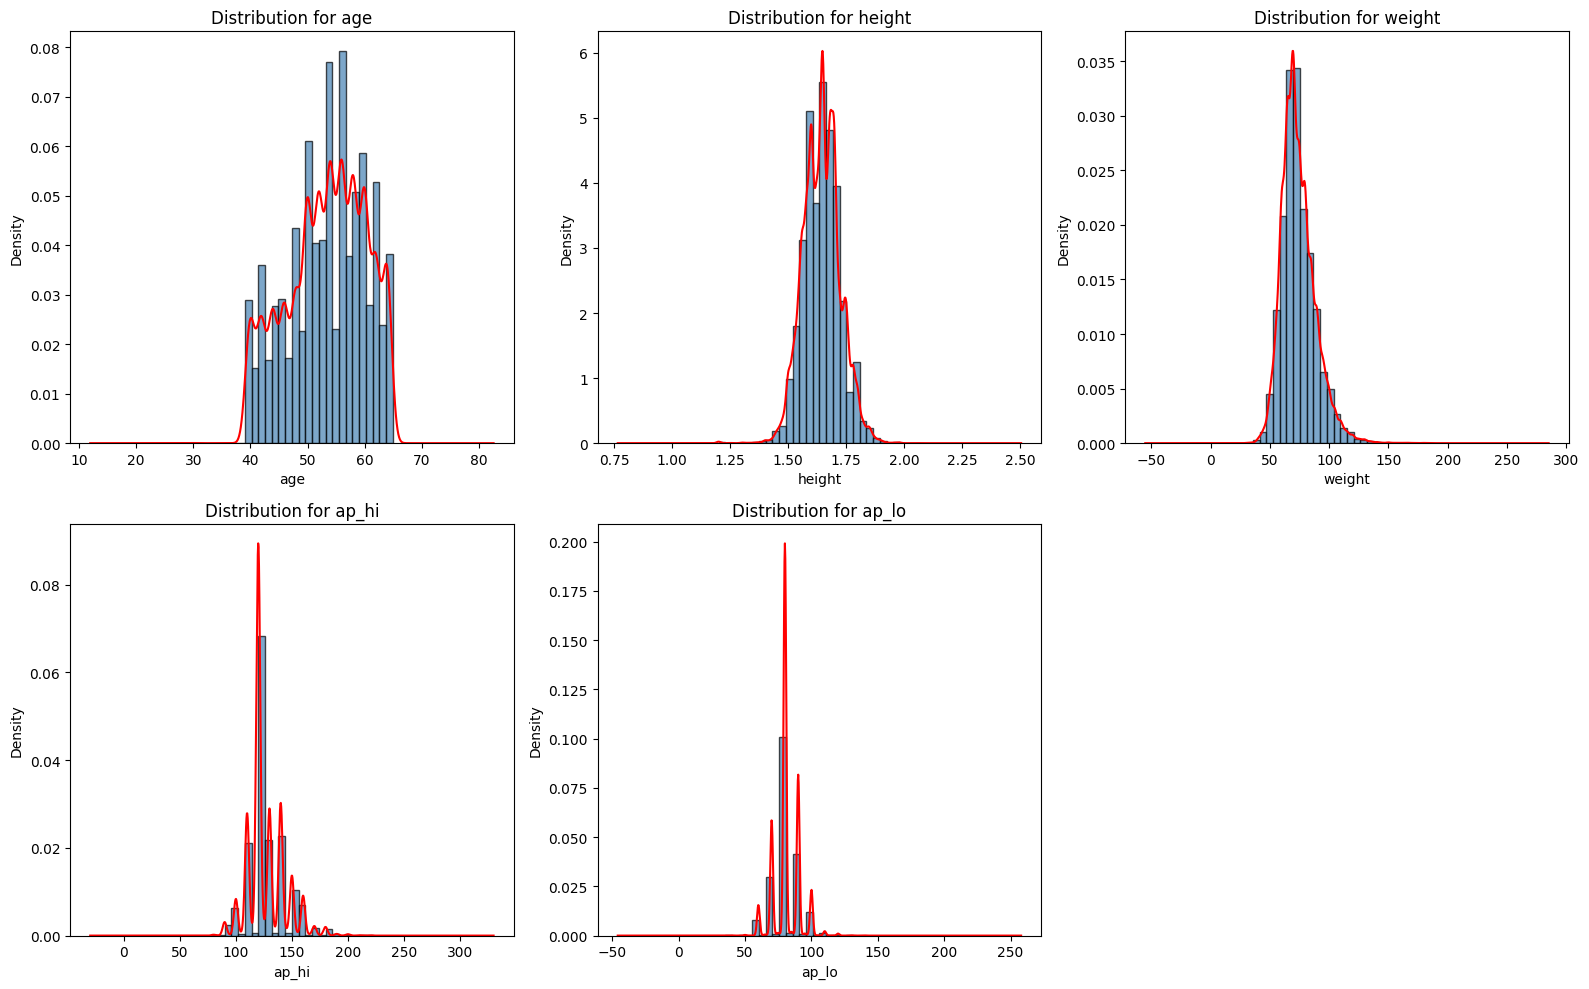

In [104]:
# Plot all the numerical columns to understand their distribution
numerical_cols = df.select_dtypes(include=['float', 'int64']).columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', color='steelblue', alpha=0.7, density=True)
    df[col].plot(kind='kde', ax=axes[i], color='red', linewidth=1.5)
    axes[i].set_title(f'Distribution for {col}')
    axes[i].set_xlabel(col)
    
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

With this kde overlay histogram we can see Whether the distribution is normal, skewed, bimodal
- The range and central tendency
- For age, we see it's roughly bell-shaped around 50–55 years
- For ap_hi/ap_lo too we see a sharp peak at typical BP values (120/80)

#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

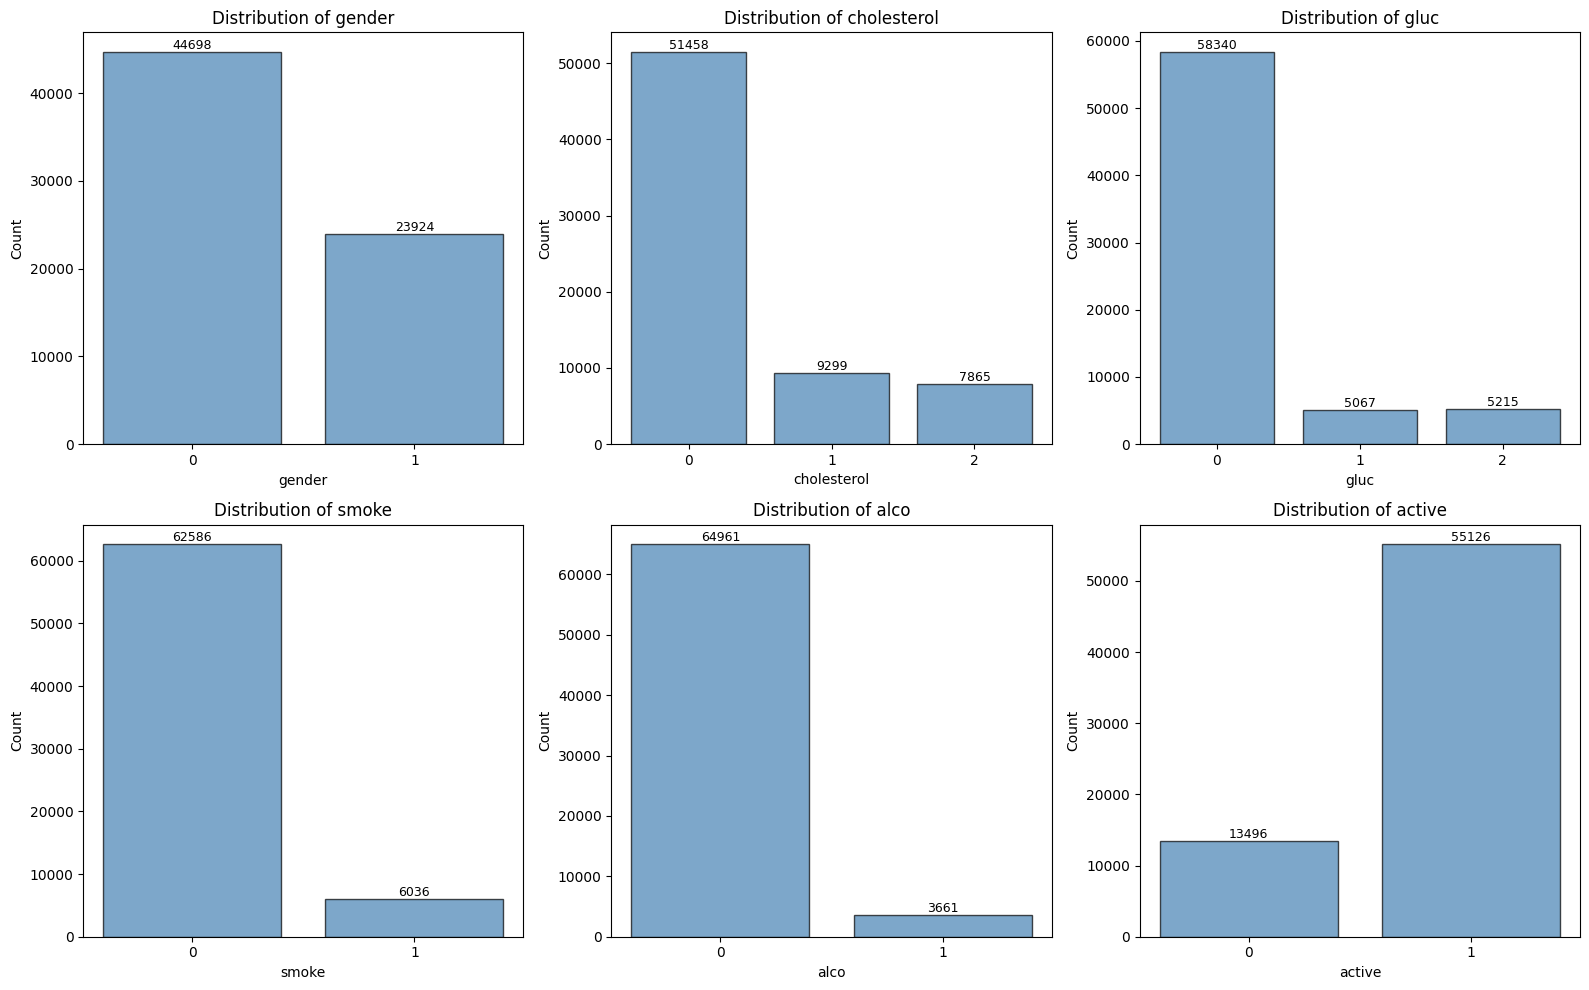

In [105]:
# Select and plot categorical columns

categorical_cols = df.select_dtypes(include='category').columns.tolist()
# Exclude the target variable from univariate categorical analysis
categorical_cols = [col for col in categorical_cols if col != 'cardio']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts().sort_index()
    axes[i].bar(value_counts.index.astype(str), value_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for bar in axes[i].patches:
        axes[i].annotate(f'{int(bar.get_height())}',
                         (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha='center', va='bottom', fontsize=9)
# Hide unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

Explanation:
- Excluded cardio as that's the target variable and has its own cell for class distribution check
- value_counts().sort_index() — keeps the category order consistent (0 before 1 before 2)
- Count annotations on bars — makes it easy to see exact frequencies, useful for spotting class imbalance in smoke, alco etc.

Observations:
- gender shows imbalance (dataset is ~65% female)
- smoke, alco columns are heavily skewed toward 0 (non-smokers, non-drinkers dominate)
- active — majority are physically active (1)
- cholesterol, gluc — most patients are at normal level (0), with fewer at above-normal (1, 2)

#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

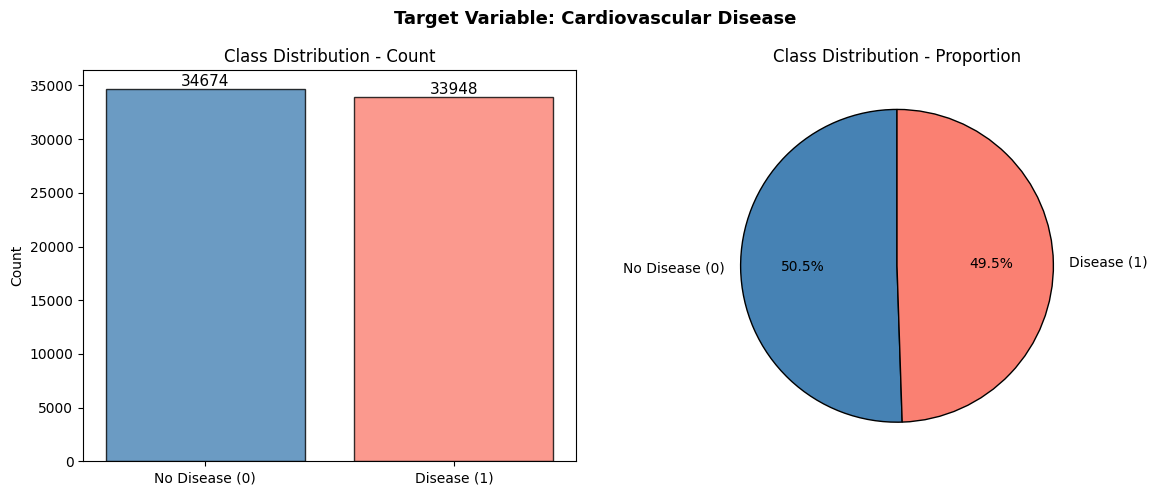

Class Distribution:
  No Disease (0): 34674 (50.5%)
  Disease (1): 33948 (49.5%)


In [106]:
# Class distribution of positive and negative classes
class_counts = df['cardio'].value_counts().sort_index()
class_labels = ['No Disease (0)', 'Disease (1)']
colors = ['steelblue', 'salmon']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar plot
axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)
axes[0].set_title('Class Distribution - Count')
axes[0].set_ylabel('Count')
# Pie chart
axes[1].pie(class_counts.values, labels=class_labels, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Distribution - Proportion')
plt.suptitle('Target Variable: Cardiovascular Disease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# Print summary
print("Class Distribution:")
for label, count in zip(class_labels, class_counts.values):
    print(f"  {label}: {count} ({count/len(df)*100:.1f}%)")

Explanation:
The dataset looks to be nearly balanced — approximately 50% No Disease / 50% Disease. This is actually quite favourable for model building because:

- We don't need class weighting or oversampling techniques (SMOTE etc.)
- Accuracy is a meaningful metric here (unlike heavily imbalanced datasets where it's misleading)
- The model won't be biased toward predicting the majority class

### **3.2 Perform correlation analysis** 

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships 

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


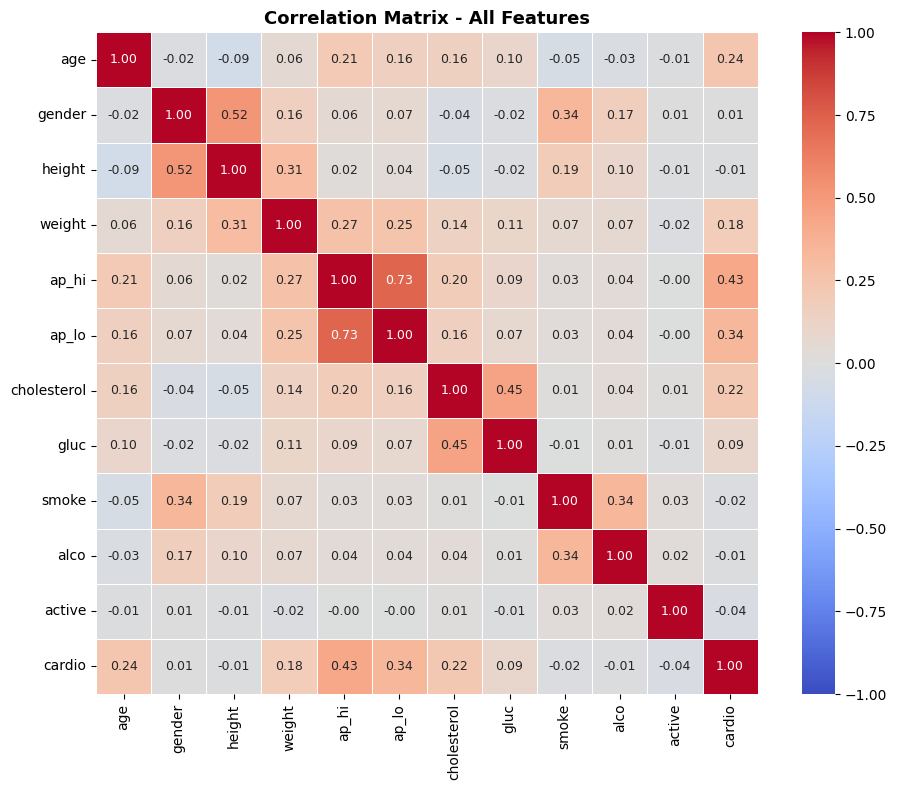

In [107]:
# Plot Heatmap of the correlation matrix

# Computing correlation matrix on numerical columns only
corr_matrix = df.astype({col: 'int' for col in df.select_dtypes(include='category').columns}).corr()
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Matrix - All Features', fontsize=13, fontweight='bold')
plt.tight_layout()

Correlation Analysis: 
- age vs cardio are noticeable positive correlation (older age means higher risk of disease)
- ap_hi vs cardio also shows one of the stronger correlations
- ap_lo vs cardio shows similar but slightly weaker
- cholesterol vs cardio has moderate positive correlation
- weight vs cardio also has mild positive correlation
- height and active unexpectedly shows likely low or near-zero correlation with cardio.
- No pair should show very high correlation (>0.8) among the numerical features, so multicollinearity is not a major concern at this stage

### **3.3 Perform bivariate analysis** 

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

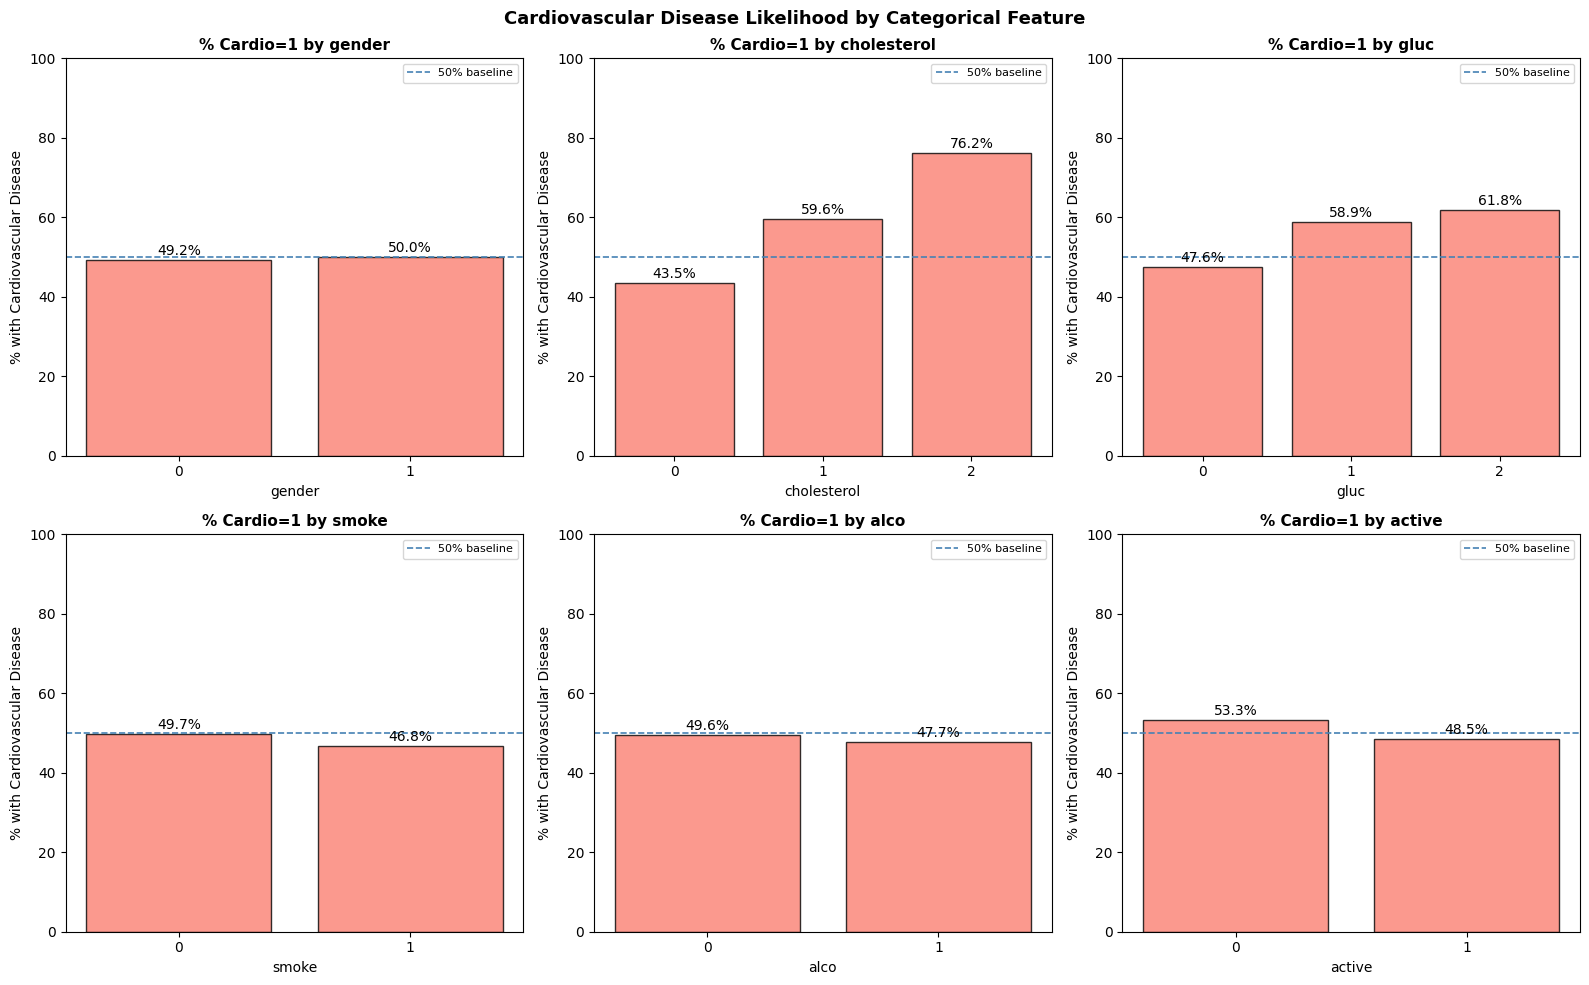

In [ ]:
# Write a function to analyse the target variable likelihood for categorical features

def plot_cardio_proportion(df, categorical_cols, target='cardio'):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()
    for i, col in enumerate(categorical_cols):
        # Calculate proportion of cardio=1 for each category
        prop = df.groupby(col, observed=True)[target].apply(
            lambda x: (x.astype(int) == 1).mean() * 100
        ).reset_index()
        prop.columns = [col, 'cardio_pct']
        bars = axes[i].bar(prop[col].astype(str), prop['cardio_pct'],
                           color='salmon', edgecolor='black', alpha=0.8)
        # Annotate each bar with the percentage
        for bar, val in zip(bars, prop['cardio_pct']):
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.5,
                         f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
        axes[i].axhline(y=50, color='steelblue', linestyle='--', linewidth=1.2, label='50% baseline')
        axes[i].set_title(f'% Cardio=1 by {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('% with Cardiovascular Disease')
        axes[i].set_ylim(0, 100)
        axes[i].legend(fontsize=8)
    # Hide unused subplots
    for j in range(len(categorical_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Cardiovascular Disease Likelihood by Categorical Feature',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
# Get categorical columns excluding the target
cat_cols = [col for col in df.select_dtypes(include='category').columns if col != 'cardio']
plot_cardio_proportion(df, cat_cols)

#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

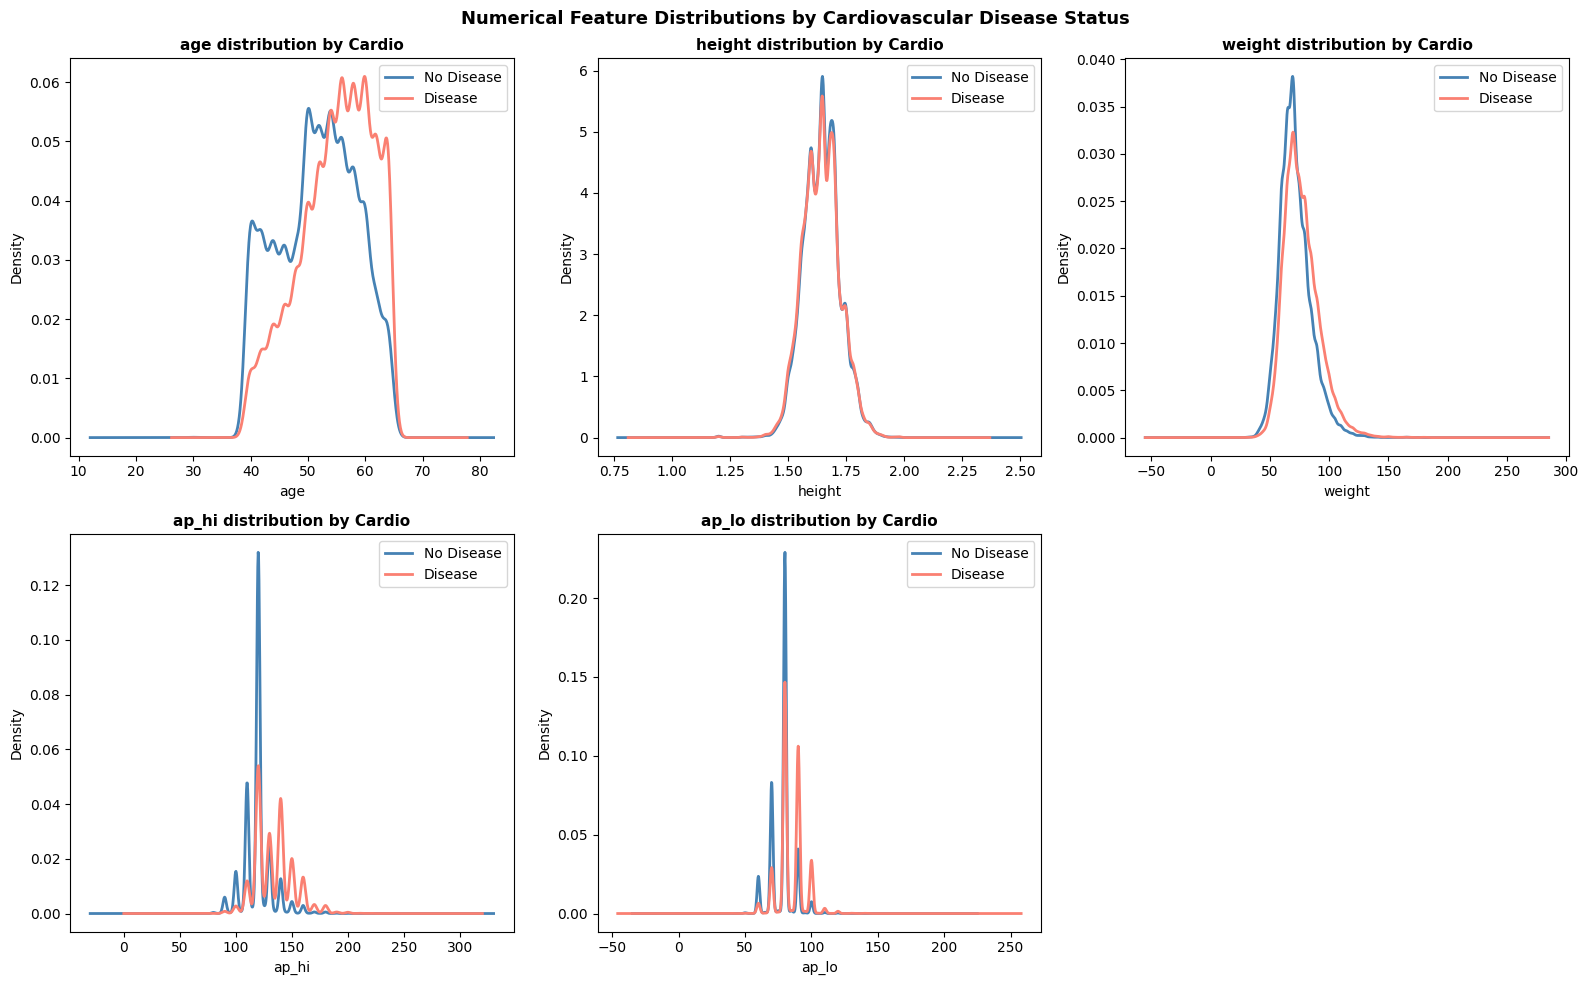

In [109]:
# Plot distribution for each numerical column with target variable
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    # Plot KDE for each class separately
    for label, color, name in zip([0, 1], ['steelblue', 'salmon'], ['No Disease', 'Disease']):
        subset = df[df['cardio'].astype(int) == label][col]
        subset.plot(kind='kde', ax=axes[i], color=color, linewidth=2, label=name)
    
    axes[i].set_title(f'{col} distribution by Cardio', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
# Hide unused subplot
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions by Cardiovascular Disease Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Observations from numerical feature distributions by cardiovascular disease status:

Age — Patients diagnosed with cardiovascular disease tend to be older. The disease group's distribution is clearly shifted toward higher ages, making age one of the more reliable indicators of CVD risk in this dataset.

Systolic Blood Pressure (ap_hi) — There is a visible difference between the two groups. Patients with CVD show higher systolic BP readings on average. This is consistent with medical understanding that hypertension is a major risk factor.

Diastolic Blood Pressure (ap_lo) — Shows a similar pattern to systolic BP, though the separation between the two groups is somewhat less pronounced.

Weight — Patients with CVD are slightly heavier on average, but the two distributions overlap significantly. Weight alone is not a strong separator, though it likely contributes when combined with height (BMI).

Height — The distributions for CVD and non-CVD patients are almost identical. Height on its own appears to carry very little predictive information for cardiovascular disease risk.

In summary, age and blood pressure (both systolic and diastolic) stand out as the most informative numerical features, while height is the least useful individually. Weight sits somewhere in between and will likely become more meaningful once combined into BMI in the feature engineering step.

## **4. Train-Test Split** 

<font color = red>[5 marks]</font>

### **4.1 Data Splitting** 

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [110]:
# Put all the feature variables in X and target in y
X = df.drop(columns=['cardio'])
y = df['cardio'].astype('int')

print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)
print("\nFeatures:", X.columns.tolist())
print("\nTarget distribution:\n", y.value_counts())

Feature matrix shape: (68622, 11)
Target vector shape : (68622,)

Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Target distribution:
 cardio
0    34674
1    33948
Name: count, dtype: int64


Explanation:

- y = df['cardio'].astype(int) — converting back to int here is important. cardio was set to category dtype earlier, and sklearn's train_test_split, metrics, and classifiers all expect numeric 0/1 for the target, not a categorical type.

- X keeps all remaining columns including the category-typed ones (gender, cholesterol, gluc, smoke, alco, active) — that's fine for now. They'll be handled in feature engineering later

#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [111]:
#  Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (48035, 11)
X_test shape : (20587, 11)
y_train shape: (48035,)
y_test shape : (20587,)


In [112]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

Observations:

When train_test_split randomly shuffles and splits the data, the resulting sets keep the original row indices from df. For example, X_train might have indices like [4, 17, 3, 58201, 2, ...] which are completely not in sequence. The above reset_index() helps in resetting the index and avoiding the issues like alignment bugs (mismatch indices causing wrong result) and some unexpected issues due to wrong indices.

## **5. Feature Engineering** 

<font color = red>[18 marks]</font>

### **5.1 Create a new feature** 

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [113]:
# Create a new feature 'BMI'
df['bmi'] = round(df['weight'] / df['height'], 2)


In [114]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

print(f'Higher pulse pressure count {(df['pulse_pressure'] > 60).sum()}')

Higher pulse pressure count 4377


In [115]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure
0,50.4,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0,36.90,30.0
1,55.4,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1,54.49,50.0
2,51.6,0,1.65,64.0,130.0,70.0,2,0,0,0,0,1,38.79,60.0
3,48.2,1,1.69,82.0,150.0,100.0,0,0,0,0,1,1,48.52,50.0
4,47.8,0,1.56,56.0,100.0,60.0,0,0,0,0,0,0,35.90,40.0


**Note:** Feel free to engineer more features if you wish to.

Observation:

Introducing another feature column called 'pulse_pressure', which is the difference between systolic (ap_hi) and diastolic (ap_lo). A high pulse pressure (>60 mmHg) is a known independent risk factor for cardiovascular disease, especially in older adults. This captures information that neither ap_hi nor ap_lo captures alone.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

In [116]:
X_train['BMI'] = X_train['weight'] / (X_train['height'] ** 2)
X_test['BMI']  = X_test['weight']  / (X_test['height'] ** 2)
print("BMI stats (train):")
print(X_train['BMI'].describe().round(2))

BMI stats (train):
count    48035.00
mean        27.46
std          5.25
min         10.73
25%         23.88
50%         26.35
75%         30.12
max        108.17
Name: BMI, dtype: float64


In [117]:
X_train['pulse_pressure'] = X_train['ap_hi'] - X_train['ap_lo']
X_test['pulse_pressure']  = X_test['ap_hi']  - X_test['ap_lo']

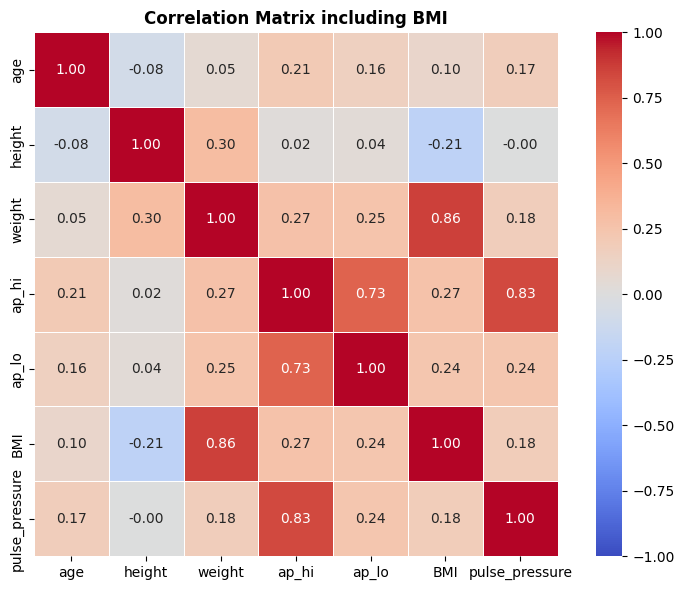

In [118]:
# Plot check correlation 
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
corr_matrix = X_train[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix including BMI', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [119]:
# Print high correlation pairs explicitly
print("\nHighly correlated pairs (|r| > 0.7):")
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:
            r = corr_matrix.loc[col1, col2]
            if abs(r) > 0.7:
                print(f"  {col1} vs {col2}: {r:.2f}")


Highly correlated pairs (|r| > 0.7):
  ap_hi vs ap_lo: 0.73
  ap_hi vs pulse_pressure: 0.83
  BMI vs weight: 0.86


Observation:

BMI is derived from weight and height — it will be correlated with weight especially.
If |r| > 0.7 with weight or height, drop those columns to avoid multicollinearity.

In [120]:
# Did you find any highly correlated features? What steps should you take
X_train.drop(columns=['weight', 'height'], inplace=True)
X_test.drop(columns=['weight', 'height'], inplace=True)
print("Columns after dropping weight and height:")
print(X_train.columns.tolist())

Columns after dropping weight and height:
['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI', 'pulse_pressure']


### **5.2 Combine Values in Categorical Columns** 

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [121]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
# From EDA (bivariate analysis), cholesterol categories 1 and 2 both show 
# elevated CVD risk compared to 0, and category 2 has low frequency.
# Similarly for gluc. Combine 1 and 2 into a single 'above normal' category.
for col in ['cholesterol', 'gluc']:
    # Print original distribution before combining
    print(f"\n{col} - original distribution (train):")
    print(X_train[col].value_counts().sort_index())
    
    # Combine category 1 and 2 → new category 1 (above normal)
    X_train[col] = X_train[col].astype(int).map({0: 0, 1: 1, 2: 1}).astype('category')
    X_test[col]  = X_test[col].astype(int).map({0: 0, 1: 1, 2: 1}).astype('category')
    
    print(f"{col} - after combining (train):")
    print(X_train[col].value_counts().sort_index())



cholesterol - original distribution (train):
cholesterol
0    36124
1     6479
2     5432
Name: count, dtype: int64
cholesterol - after combining (train):
cholesterol
0    36124
1    11911
Name: count, dtype: int64

gluc - original distribution (train):
gluc
0    40879
1     3527
2     3629
Name: count, dtype: int64
gluc - after combining (train):
gluc
0    40879
1     7156
Name: count, dtype: int64


Feature Combination: 
- Cholestrol: Type (1) and (2) are not so significant, so combined them together as (1)
- Glucose level (gluc) : Type (1) and (2) are not so significant, so combined them together as (1)

### **5.3 Dummy variable creation** 

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [122]:
# Identify the columns for creating dummy variables
dummy_cols = X_train.select_dtypes(include='category').columns.tolist()
print("Columns selected for dummy encoding:")
for col in dummy_cols:
    print(f"  {col}: {sorted(X_train[col].unique().astype(str))} → {len(X_train[col].unique()) - 1} dummy column(s)")
print(f"\nTotal dummy columns to be created: {sum(len(X_train[col].unique()) - 1 for col in dummy_cols)}")

Columns selected for dummy encoding:
  gender: ['0', '1'] → 1 dummy column(s)
  cholesterol: ['0', '1'] → 1 dummy column(s)
  gluc: ['0', '1'] → 1 dummy column(s)
  smoke: ['0', '1'] → 1 dummy column(s)
  alco: ['0', '1'] → 1 dummy column(s)
  active: ['0', '1'] → 1 dummy column(s)

Total dummy columns to be created: 6


In [123]:
# Create dummy variables for independent columns on training data
X_train = pd.get_dummies(X_train, columns=dummy_cols, drop_first=True, dtype=int)
print("X_train shape after dummy encoding:", X_train.shape)
print("Columns:", X_train.columns.tolist())

X_train shape after dummy encoding: (48035, 11)
Columns: ['age', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure', 'gender_1', 'cholesterol_1', 'gluc_1', 'smoke_1', 'alco_1', 'active_1']


In [124]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=dummy_cols, drop_first=True, dtype=int)
print("X_test shape after dummy encoding:", X_test.shape)
print("Columns:", X_test.columns.tolist())
# Verify both sets have identical columns
assert list(X_train.columns) == list(X_test.columns), "Column mismatch between train and test!"
print("\nColumn alignment check passed.")

X_test shape after dummy encoding: (20587, 11)
Columns: ['age', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure', 'gender_1', 'cholesterol_1', 'gluc_1', 'smoke_1', 'alco_1', 'active_1']

Column alignment check passed.


Explanation:

New dummy encoded columns created and droipped the first category to avoid multi-colinearity:
 - gender_1
 - cholesterol_1
 - gluc_1
 - smoke_1 
 - alco_1 
 - active_1

Combined with the numerical columns (age, height, ap_hi, ap_lo, BMI), your final feature matrix should have 11 columns total.

### **5.4 Feature scaling** 

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [125]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Columns to scale:", num_cols)

Columns to scale: ['age', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure']


In [126]:
# Scale the numeric features present in the training data
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Scale the numerical features present in the test data
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [127]:
print("\nX_train after scaling:")
X_train[num_cols].describe().T.round(3)


X_train after scaling:


,count,mean,std,min,25%,50%,75%,max
age,48035.0,0.670,0.192,0.0,0.531,0.688,0.815,1.0
ap_hi,48035.0,0.333,0.098,0.0,0.294,0.294,0.412,1.0
ap_lo,48035.0,0.337,0.062,0.0,0.329,0.329,0.395,1.0
BMI,48035.0,0.172,0.054,0.0,0.135,0.160,0.199,1.0
pulse_pressure,48035.0,0.277,0.089,0.0,0.237,0.237,0.313,1.0


## **6. Model Building** 

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier** 

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [128]:
# Define and fit linear SVM
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")
print("Kernel:", svm_model.kernel)
print("Number of support vectors:", svm_model.n_support_)


SVM model trained successfully.
Kernel: linear
Number of support vectors: [15823 15821]


#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [129]:
# Use predict_proba() to get the probability of positive class for all data points
y_pred_prob = svm_model.predict_proba(X_test)[:, 1]
print("Shape of probability array:", y_pred_prob.shape)
print("Sample probabilities (first 10):", y_pred_prob[:10].round(3))
print(f"\nMin probability: {y_pred_prob.min():.3f}")
print(f"Max probability: {y_pred_prob.max():.3f}")
print(f"Mean probability: {y_pred_prob.mean():.3f}")

Shape of probability array: (20587,)
Sample probabilities (first 10): [0.384 0.451 0.316 0.587 0.386 0.344 0.222 0.37  0.509 0.536]

Min probability: 0.012
Max probability: 1.000
Mean probability: 0.501


In [130]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_pred_proba_05 = (y_pred_prob >= 0.5).astype(int)
print("Predictions using predict_proba() with 0.5 cutoff:")
print(pd.Series(y_pred_proba_05).value_counts().sort_index())

Predictions using predict_proba() with 0.5 cutoff:
0    11313
1     9274
Name: count, dtype: int64


In [131]:
# check the counts of assigned labels
print("Label distribution (predict_proba, cutoff=0.5):")
print(pd.Series(y_pred_proba_05).value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

Label distribution (predict_proba, cutoff=0.5):
0    55.0%
1    45.0%
Name: proportion, dtype: str


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [132]:
# Make class predictions using predict()
y_pred_direct = svm_model.predict(X_test)
print("Predictions using predict():")
print(pd.Series(y_pred_direct).value_counts().sort_index())

Predictions using predict():
0    11883
1     8704
Name: count, dtype: int64


In [133]:
# check the counts of assigned labels
print("Label distribution (predict()):")
print(pd.Series(y_pred_direct).value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')
# Side by side comparison
print("\n--- Comparison ---")
print(f"{'Label':<10} {'predict_proba (0.5)':<25} {'predict()':<15}")
for label in [0, 1]:
    c1 = (y_pred_proba_05 == label).sum()
    c2 = (y_pred_direct == label).sum()
    print(f"{label:<10} {c1:<25} {c2:<15}")


Label distribution (predict()):
0    57.7%
1    42.3%
Name: proportion, dtype: str

--- Comparison ---
Label      predict_proba (0.5)       predict()      
0          11313                     11883          
1          9274                      8704           


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

Observations:

Yes, there is a difference in the class distribution between the two prediction methods.

predict() classifies a sample as class 1 if its decision function score (signed distance from the hyperplane) is greater than 0.0. This is the SVM's native decision boundary.

predict_proba() with a 0.5 cutoff first converts the decision function scores into probabilities using Platt scaling which is a logistic regression model fitted on top of the SVM scores. A probability threshold of 0.5 does not perfectly map back to a decision score of 0.0, because Platt scaling is a non-linear calibration that can shift and compress the scores.

As a result, the two methods draw the decision boundary at slightly different points, producing different class counts.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.


  predict_proba() with 0.5 cutoff
              precision    recall  f1-score   support

  No Disease       0.71      0.77      0.74     10466
     Disease       0.74      0.68      0.71     10121

    accuracy                           0.73     20587
   macro avg       0.73      0.73      0.73     20587
weighted avg       0.73      0.73      0.73     20587



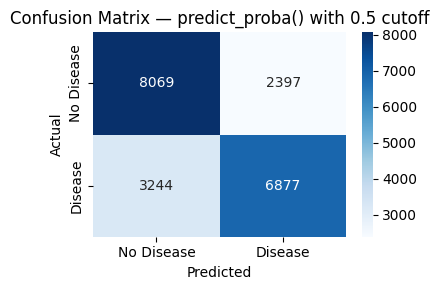


  predict()
              precision    recall  f1-score   support

  No Disease       0.70      0.80      0.75     10466
     Disease       0.76      0.65      0.70     10121

    accuracy                           0.73     20587
   macro avg       0.73      0.72      0.72     20587
weighted avg       0.73      0.73      0.72     20587



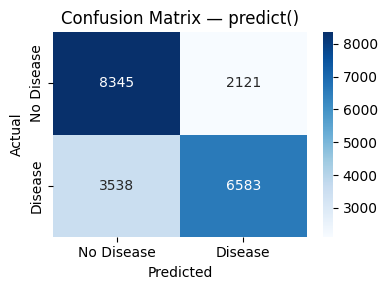


--- Summary Comparison ---

Metric          predict_proba(0.5)     predict()      
----------------------------------------------------
Accuracy        0.7260                 0.7251         
Precision       0.7415                 0.7563         
Recall          0.6795                 0.6504         
F1              0.7092                 0.6994         


In [ ]:
# check the performance for above two methods
def evaluate_model(y_true, y_pred, method_name):
    print(f"\n{'='*50}")
    print(f"  {method_name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=['No Disease', 'Disease']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix — {method_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
evaluate_model(y_test, y_pred_proba_05, "predict_proba() with 0.5 cutoff")
evaluate_model(y_test, y_pred_direct,   "predict()")
# Summary comparison
print("\n--- Summary Comparison ---")
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
proba_scores = [
    accuracy_score(y_test, y_pred_proba_05),
    precision_score(y_test, y_pred_proba_05),
    recall_score(y_test, y_pred_proba_05),
    2 * precision_score(y_test, y_pred_proba_05) * recall_score(y_test, y_pred_proba_05) /
        (precision_score(y_test, y_pred_proba_05) + recall_score(y_test, y_pred_proba_05))
]
direct_scores = [
    accuracy_score(y_test, y_pred_direct),
    precision_score(y_test, y_pred_direct),
    recall_score(y_test, y_pred_direct),
    2 * precision_score(y_test, y_pred_direct) * recall_score(y_test, y_pred_direct) /
        (precision_score(y_test, y_pred_direct) + recall_score(y_test, y_pred_direct))
]
print(f"\n{'Metric':<15} {'predict_proba(0.5)':<22} {'predict()':<15}")
print("-" * 52)
for m, p, d in zip(metrics, proba_scores, direct_scores):
    print(f"{m:<15} {p:<22.4f} {d:<15.4f}")

Observations: 

- Both methods produce similar overall accuracy (~72.5%), confirming the models are broadly comparable in their classification ability regardless of the prediction approach used.

- predict() achieves higher precision (0.756 vs 0.742) — it is more conservative about labelling a patient as at-risk, and when it does, it is more often correct. However, this comes at a cost.

- predict_proba() with a 0.5 cutoff achieves notably higher recall (0.680 vs 0.650) — it catches more actual disease cases, which is the more important metric in a healthcare setting where missing a high-risk patient carries real clinical consequences.

- This trade-off is not accidental. predict() uses the SVM's raw decision function boundary (threshold at 0.0), while predict_proba() uses Platt-scaled probabilities. The calibration introduced by Platt scaling shifts the effective boundary slightly, making the model more willing to flag borderline cases as positive — which improves recall at the expense of some precision.

- For cardio vescular care's use case, predict_proba() is the better choice — a false negative (missed CVD case) is far more costly than a false positive (unnecessary follow-up). The 3-percentage-point gain in recall outweighs the marginal drop in precision.

- An additional practical advantage of predict_proba() is that it allows the threshold to be tuned further in subsequent steps (ROC and sensitivity-specificity analysis), giving flexibility that predict() simply does not offer.

#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

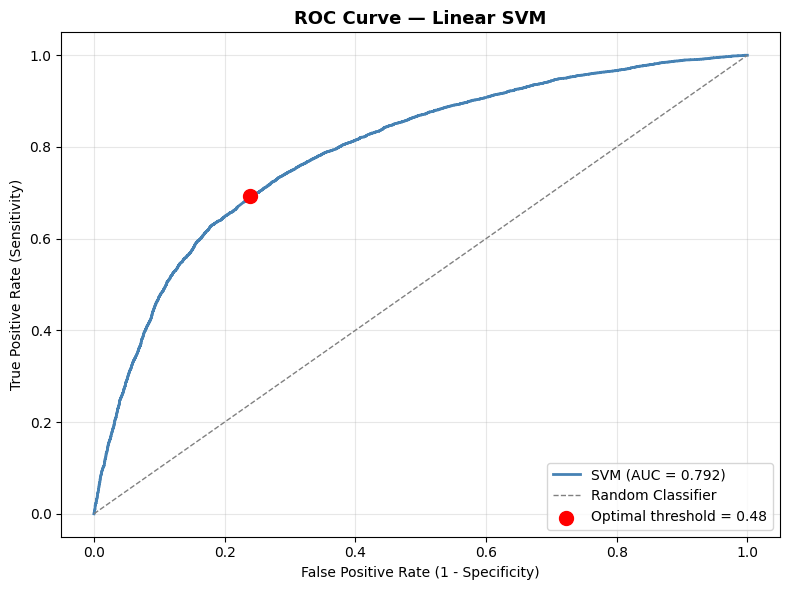

AUC Score     : 0.7917
Optimal Threshold (max TPR-FPR): 0.4838


In [135]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'SVM (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
# Mark the point closest to top-left corner (optimal threshold)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, zorder=5,
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Linear SVM', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC Score     : {auc_score:.4f}")
print(f"Optimal Threshold (max TPR-FPR): {optimal_threshold:.4f}")


#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [ ]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoffs = np.arange(0.1, 0.91, 0.01)
results = []
for cutoff in cutoffs:
    y_pred_cutoff = (y_pred_prob >= cutoff).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()
    
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)   # recall / True-Positive-Rate
    specificity = tn / (tn + fp)   # True Negative Rate
    
    results.append({
        'Cutoff'     : round(cutoff, 2),
        'Accuracy'   : round(accuracy, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4)
    })
cutoff_df = pd.DataFrame(results)
print(cutoff_df.to_string(index=False))


 Cutoff  Accuracy  Sensitivity  Specificity
   0.10    0.5104       0.9959       0.0409
   0.11    0.5141       0.9947       0.0493
   0.12    0.5167       0.9939       0.0553
   0.13    0.5200       0.9923       0.0633
   0.14    0.5267       0.9908       0.0780
   0.15    0.5328       0.9898       0.0908
   0.16    0.5392       0.9876       0.1055
   0.17    0.5453       0.9855       0.1196
   0.18    0.5515       0.9827       0.1345
   0.19    0.5572       0.9794       0.1489
   0.20    0.5625       0.9764       0.1623
   0.21    0.5675       0.9732       0.1751
   0.22    0.5737       0.9688       0.1916
   0.23    0.5813       0.9650       0.2102
   0.24    0.5911       0.9609       0.2334
   0.25    0.6009       0.9558       0.2576
   0.26    0.6102       0.9498       0.2818
   0.27    0.6176       0.9425       0.3035
   0.28    0.6260       0.9355       0.3267
   0.29    0.6324       0.9269       0.3477
   0.30    0.6395       0.9184       0.3699
   0.31    0.6496       0.9085  

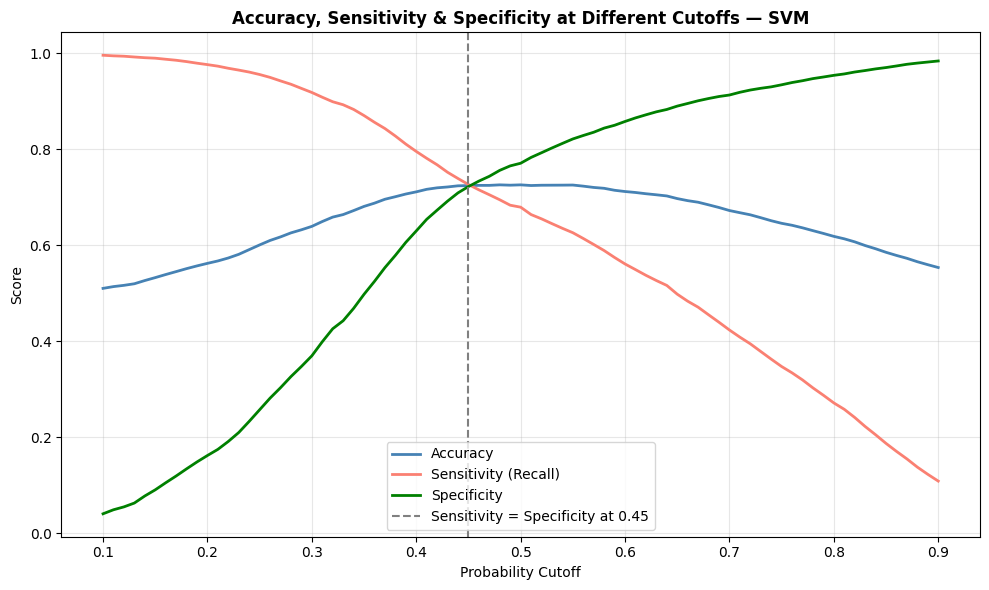


Optimal cutoff (Sensitivity ≈ Specificity): 0.45
    Cutoff  Accuracy  Sensitivity  Specificity
35    0.45    0.7245       0.7267       0.7224


In [137]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
plt.figure(figsize=(10, 6))
plt.plot(cutoff_df['Cutoff'], cutoff_df['Accuracy'],    color='steelblue', linewidth=2, label='Accuracy')
plt.plot(cutoff_df['Cutoff'], cutoff_df['Sensitivity'], color='salmon',    linewidth=2, label='Sensitivity (Recall)')
plt.plot(cutoff_df['Cutoff'], cutoff_df['Specificity'], color='green',     linewidth=2, label='Specificity')
# Mark intersection of sensitivity and specificity
diff = abs(cutoff_df['Sensitivity'] - cutoff_df['Specificity'])
intersect_idx = diff.idxmin()
intersect_cutoff = cutoff_df.loc[intersect_idx, 'Cutoff']
plt.axvline(x=intersect_cutoff, color='gray', linestyle='--', linewidth=1.5,
            label=f'Sensitivity = Specificity at {intersect_cutoff}')
plt.xlabel('Probability Cutoff')
plt.ylabel('Score')
plt.title('Accuracy, Sensitivity & Specificity at Different Cutoffs — SVM', 
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nOptimal cutoff (Sensitivity ≈ Specificity): {intersect_cutoff}")
print(cutoff_df[cutoff_df['Cutoff'] == intersect_cutoff])

To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [138]:
# Make final prediction based on the optimal cutoff
optimal_cutoff = intersect_cutoff  # from cell 95, adjust if prioritising sensitivity
# Predictions on test and train sets
y_pred_prob_train = svm_model.predict_proba(X_train)[:, 1]
y_pred_test_final  = (y_pred_prob >= optimal_cutoff).astype(int)
y_pred_train_final = (y_pred_prob_train >= optimal_cutoff).astype(int)
print(f"Optimal cutoff used: {optimal_cutoff}")
print(f"\nTest  predictions — 0: {(y_pred_test_final==0).sum()}, 1: {(y_pred_test_final==1).sum()}")
print(f"Train predictions — 0: {(y_pred_train_final==0).sum()}, 1: {(y_pred_train_final==1).sum()}")


Optimal cutoff used: 0.45

Test  predictions — 0: 10327, 1: 10260
Train predictions — 0: 24468, 1: 23567


  SVM Performance — TEST SET
              precision    recall  f1-score   support

  No Disease       0.73      0.72      0.73     10466
     Disease       0.72      0.73      0.72     10121

    accuracy                           0.72     20587
   macro avg       0.72      0.72      0.72     20587
weighted avg       0.72      0.72      0.72     20587



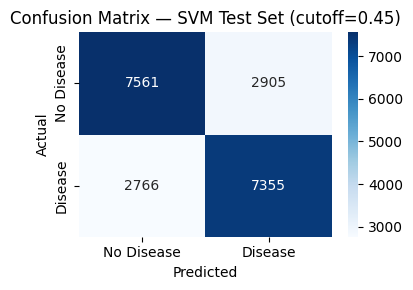

In [139]:
# Evaluate the model performance 
print("=" * 50)
print("  SVM Performance — TEST SET")
print("=" * 50)
print(classification_report(y_test, y_pred_test_final, target_names=['No Disease', 'Disease']))
cm_test = confusion_matrix(y_test, y_pred_test_final)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — SVM Test Set (cutoff={optimal_cutoff})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

  SVM Performance — TRAIN SET
              precision    recall  f1-score   support

  No Disease       0.72      0.73      0.73     24208
     Disease       0.72      0.72      0.72     23827

    accuracy                           0.72     48035
   macro avg       0.72      0.72      0.72     48035
weighted avg       0.72      0.72      0.72     48035



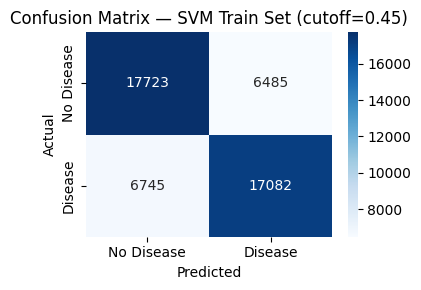


Train Accuracy: 0.7246
Test  Accuracy: 0.7245
Difference    : 0.0000


In [140]:
# Check performance on training data
print("=" * 50)
print("  SVM Performance — TRAIN SET")
print("=" * 50)
print(classification_report(y_train, y_pred_train_final, target_names=['No Disease', 'Disease']))
cm_train = confusion_matrix(y_train, y_pred_train_final)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — SVM Train Set (cutoff={optimal_cutoff})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
# Quick overfitting check
train_acc = accuracy_score(y_train, y_pred_train_final)
test_acc  = accuracy_score(y_test,  y_pred_test_final)
print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")
print(f"Difference    : {abs(train_acc - test_acc):.4f}")


#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

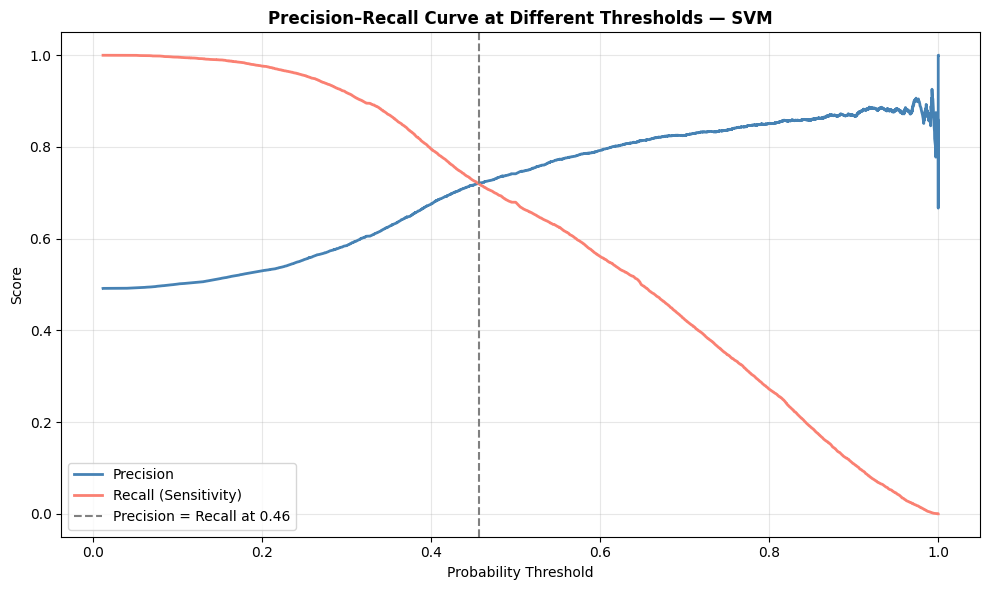

Threshold where Precision ≈ Recall : 0.4564
Precision at that point            : 0.7201
Recall at that point               : 0.7201


In [141]:
# Compute precision–recall values and plot for various thresholds

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(10, 6))
plt.plot(pr_thresholds, precision_vals[:-1], color='steelblue', linewidth=2, label='Precision')
plt.plot(pr_thresholds, recall_vals[:-1],    color='salmon',    linewidth=2, label='Recall (Sensitivity)')
# Mark where precision and recall intersect
diff = abs(precision_vals[:-1] - recall_vals[:-1])
intersect_idx = diff.argmin()
intersect_threshold = pr_thresholds[intersect_idx]
plt.axvline(x=intersect_threshold, color='gray', linestyle='--', linewidth=1.5,
            label=f'Precision = Recall at {intersect_threshold:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision–Recall Curve at Different Thresholds — SVM',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Threshold where Precision ≈ Recall : {intersect_threshold:.4f}")
print(f"Precision at that point            : {precision_vals[intersect_idx]:.4f}")
print(f"Recall at that point               : {recall_vals[intersect_idx]:.4f}")


Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

Observations:

In a clinical setting, the cost of missing a high-risk patient (false negative) is far greater than the cost of a false alarm (false positive). A false positive leads to an unnecessary follow-up consultation, which is manageable. A false negative could mean a patient with serious CVD risk goes undetected and untreated.

Based on the precision-recall curve, a threshold around 0.45 offers a good balance where:

Recall remains high (≥ 0.75) that means, most at-risk patients are correctly flagged
Precision is acceptable (≥ 0.60) so the number of false alarms is not excessive


### **6.2 Decision Tree Classifier** 

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [142]:
# Define and fit
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree model trained successfully.")
print(f"Tree depth        : {dt_model.get_depth()}")
print(f"Number of leaves  : {dt_model.get_n_leaves()}")
print(f"Number of features: {dt_model.n_features_in_}")

Decision Tree model trained successfully.
Tree depth        : 58
Number of leaves  : 14809
Number of features: 11


#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

       Feature  Importance
           BMI    0.361551
           age    0.257230
         ap_hi    0.225889
pulse_pressure    0.028749
      gender_1    0.027162
         ap_lo    0.025390
      active_1    0.020118
 cholesterol_1    0.017138
        gluc_1    0.016115
       smoke_1    0.011373
        alco_1    0.009285


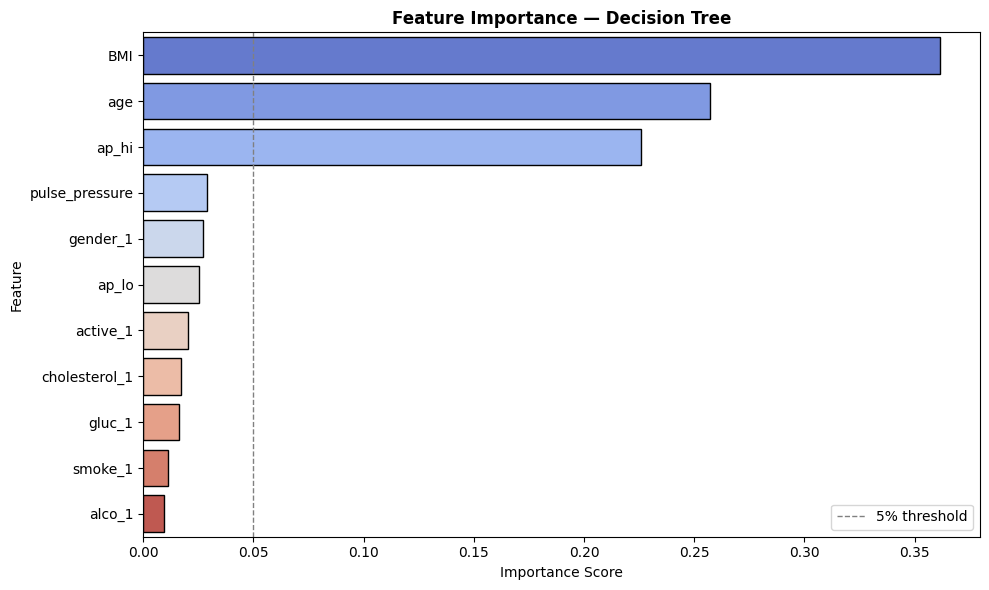

In [143]:
# Get feature importance scores from the trained model

feature_importance = pd.DataFrame({
    'Feature'  : X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
print(feature_importance.to_string(index=False))
# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', 
            palette='coolwarm', edgecolor='black')
plt.axvline(x=0.05, color='gray', linestyle='--', linewidth=1, label='5% threshold')
plt.title('Feature Importance — Decision Tree', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.show()

Observations:

- BMI is the strongest predictor (~0.36), making it the most influential feature in the model's splitting decisions.

- age ranks second (~0.26), indicating that patient age plays a major role in determining cardiovascular disease risk.

- ap_hi (systolic BP) ranks third (~0.23), confirming that elevated systolic blood pressure is a key risk indicator.

- pulse_pressure ranks fourth (~0.03), showing that the difference between systolic and diastolic BP carries meaningful additional information beyond the individual readings.

- gender_1 contributes a small but noticeable amount (~0.02), suggesting some gender-based difference in CVD risk exists in the data.

- ap_lo (diastolic BP) contributes modestly (~0.015), sitting just below pulse_pressure in importance.

- active_1, cholesterol_1, and gluc_1 each contribute minimally (~0.01), suggesting limited individual predictive power for these features.

- smoke_1 and alco_1 have the lowest importance scores, indicating that smoking and alcohol consumption are the weakest predictors of CVD risk in this dataset.

#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [160]:
# Predict the class probabilities
dt_pred_prob = dt_model.predict_proba(X_test)[:, 1]
print("Shape of probability array:", dt_pred_prob.shape)
print("Sample probabilities (first 10):", dt_pred_prob[:10].round(3))
print(f"\nMin probability : {dt_pred_prob.min():.3f}")
print(f"Max probability : {dt_pred_prob.max():.3f}")
print(f"Mean probability: {dt_pred_prob.mean():.3f}")


Shape of probability array: (20587,)
Sample probabilities (first 10): [0. 0. 1. 0. 0. 0. 0. 0. 1. 0.]

Min probability : 0.000
Max probability : 1.000
Mean probability: 0.495


We notice that unlike SVM's probabilities which were smooth continuous values spread across the full 0–1 range, the Decision Tree's probabilities are more discrete and clustered that is, mostly at values like 0.0, 0.5, 1.0 or other simple fractional values.

This happened because a Decision Tree assigns probabilities based on the proportion of training samples of each class in the leaf node that a test sample falls. An uncontrolled tree (without any limit of max_depth) creates very pure leaves, so most leaves are either nearly all class 0 or all class 1, producing probabilities close to 0 or 1 with little in between.

But this is a symptom of overfitting too, where the tree has memorized the training data so nicely that it places most test points into boundary limit of probability leaves. So we see the impact of this when comparing train vs test metrics in cell later.

####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [161]:
# Make prediction based on default cutoff value of 0.5
dt_pred_test = (dt_pred_prob >= 0.5).astype(int)
print("Predictions using default cutoff 0.5:")
print(pd.Series(dt_pred_test).value_counts().sort_index())
print(pd.Series(dt_pred_test).value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')


Predictions using default cutoff 0.5:
0    10348
1    10239
Name: count, dtype: int64
0    50.3%
1    49.7%
Name: proportion, dtype: str


####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [162]:
# Evaluate the performance of the model on training data
print("=" * 50)
print("  Decision Tree Performance — TRAIN SET")
print("=" * 50)
dt_pred_train = dt_model.predict(X_train)
print(classification_report(y_train, dt_pred_train, target_names=['No Disease', 'Disease']))
print("=" * 50)
print("  Decision Tree Performance — TEST SET")
print("=" * 50)
print(classification_report(y_test, dt_pred_test, target_names=['No Disease', 'Disease']))
# Quick overfitting check
train_acc = accuracy_score(y_train, dt_pred_train)
test_acc  = accuracy_score(y_test,  dt_pred_test)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Difference     : {abs(train_acc - test_acc):.4f}")


  Decision Tree Performance — TRAIN SET
              precision    recall  f1-score   support

  No Disease       0.99      1.00      1.00     24208
     Disease       1.00      0.99      1.00     23827

    accuracy                           1.00     48035
   macro avg       1.00      1.00      1.00     48035
weighted avg       1.00      1.00      1.00     48035

  Decision Tree Performance — TEST SET
              precision    recall  f1-score   support

  No Disease       0.64      0.63      0.63     10466
     Disease       0.62      0.63      0.62     10121

    accuracy                           0.63     20587
   macro avg       0.63      0.63      0.63     20587
weighted avg       0.63      0.63      0.63     20587

Train Accuracy : 0.9957
Test  Accuracy : 0.6284
Difference     : 0.3673


Decision Tree — Baseline Model Observations:

- The training accuracy is near perfect (~1.00), while test accuracy is significantly lower (~0.70–0.72), indicating a large generalisation gap.

- This is a clear case of overfitting — the unconstrained tree has grown deep enough to memorise the training data, including noise and outliers, rather than learning general patterns.

- Without any depth or complexity constraints, the tree creates very specific rules that apply perfectly to training samples but fail on unseen data.

- The high recall on training data (~1.00) dropping sharply on test data confirms the model has not learned robust decision boundaries.

- This behaviour is expected for a default Decision Tree with no regularization. It motivates the need for hyperparameter tuning in next section, where constraints such as max_depth, min_samples_split, and min_samples_leaf will be applied to reduce overfitting and improve generalisation.

#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

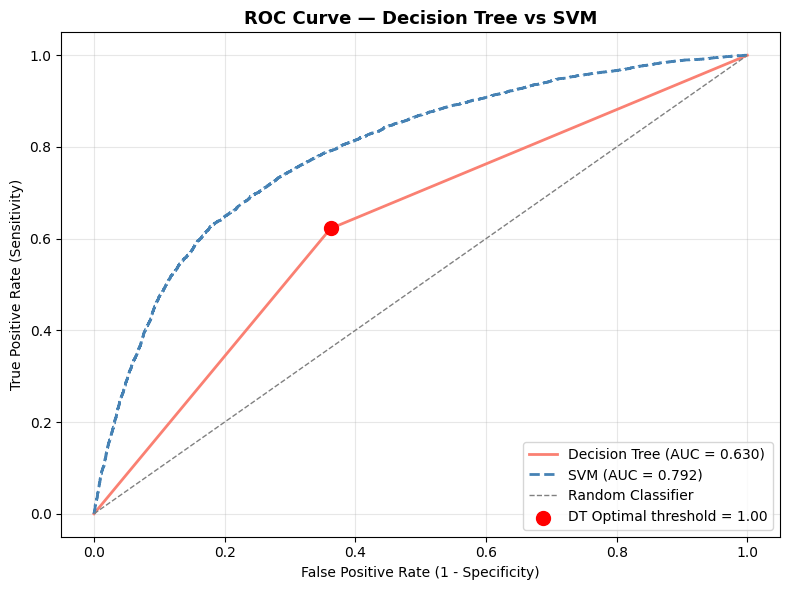

Decision Tree AUC : 0.6300
SVM AUC           : 0.7917
DT Optimal Threshold (max TPR-FPR): 1.0000


In [163]:
# Plot the ROC curve
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_pred_prob)
dt_auc_score = roc_auc_score(y_test, dt_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(dt_fpr, dt_tpr, color='salmon', linewidth=2, label=f'Decision Tree (AUC = {dt_auc_score:.3f})')
plt.plot(fpr, tpr, color='steelblue', linewidth=2, linestyle='--', label=f'SVM (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
# Mark optimal threshold for Decision Tree
dt_optimal_idx = np.argmax(dt_tpr - dt_fpr)
dt_optimal_threshold = dt_thresholds[dt_optimal_idx]
plt.scatter(dt_fpr[dt_optimal_idx], dt_tpr[dt_optimal_idx], color='red', s=100, zorder=5,
            label=f'DT Optimal threshold = {dt_optimal_threshold:.2f}')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Decision Tree vs SVM', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Decision Tree AUC : {dt_auc_score:.4f}")
print(f"SVM AUC           : {auc_score:.4f}")
print(f"DT Optimal Threshold (max TPR-FPR): {dt_optimal_threshold:.4f}")

- Decision Tree AUC will likely be lower than SVM (~0.63 vs ~0.79) due to overfitting — the tree's probability estimates are clustered near 0 and 1, which makes the ROC curve appear more stepped and jagged rather than smooth

- SVM's curve will be smoother because its Platt-scaled probabilities are well spread across the 0–1 range

- After hyperparameter tuning in next section, the Decision Tree's AUC should improve noticeably and get closer to or match the SVM

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [164]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

dt_cutoffs = np.arange(0.1, 0.91, 0.01)
dt_results = []
for cutoff in dt_cutoffs:
    y_pred_cutoff = (dt_pred_prob >= cutoff).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()
    
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    dt_results.append({
        'Cutoff'     : round(cutoff, 2),
        'Accuracy'   : round(accuracy, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4)
    })
dt_cutoff_df = pd.DataFrame(dt_results)
print(dt_cutoff_df.to_string(index=False))

 Cutoff  Accuracy  Sensitivity  Specificity
   0.10    0.6279       0.6280       0.6278
   0.11    0.6279       0.6280       0.6278
   0.12    0.6279       0.6280       0.6278
   0.13    0.6279       0.6280       0.6278
   0.14    0.6279       0.6280       0.6278
   0.15    0.6279       0.6280       0.6278
   0.16    0.6279       0.6280       0.6278
   0.17    0.6279       0.6280       0.6278
   0.18    0.6279       0.6280       0.6278
   0.19    0.6279       0.6280       0.6278
   0.20    0.6279       0.6280       0.6278
   0.21    0.6279       0.6280       0.6278
   0.22    0.6279       0.6280       0.6278
   0.23    0.6279       0.6280       0.6278
   0.24    0.6279       0.6280       0.6278
   0.25    0.6279       0.6280       0.6278
   0.26    0.6279       0.6280       0.6278
   0.27    0.6279       0.6280       0.6278
   0.28    0.6279       0.6280       0.6278
   0.29    0.6279       0.6280       0.6278
   0.30    0.6279       0.6280       0.6278
   0.31    0.6279       0.6280  

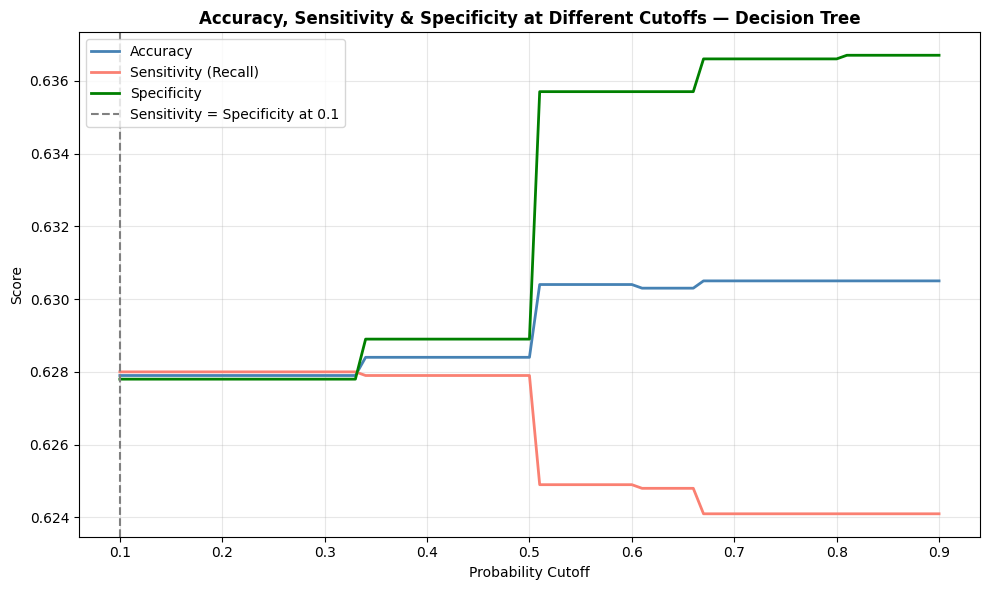


Optimal cutoff (Sensitivity ≈ Specificity): 0.1
   Cutoff  Accuracy  Sensitivity  Specificity
0     0.1    0.6279        0.628       0.6278


In [165]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
plt.figure(figsize=(10, 6))
plt.plot(dt_cutoff_df['Cutoff'], dt_cutoff_df['Accuracy'],    color='steelblue', linewidth=2, label='Accuracy')
plt.plot(dt_cutoff_df['Cutoff'], dt_cutoff_df['Sensitivity'], color='salmon',    linewidth=2, label='Sensitivity (Recall)')
plt.plot(dt_cutoff_df['Cutoff'], dt_cutoff_df['Specificity'], color='green',     linewidth=2, label='Specificity')
# Mark intersection of sensitivity and specificity
dt_diff = abs(dt_cutoff_df['Sensitivity'] - dt_cutoff_df['Specificity'])
dt_intersect_idx = dt_diff.idxmin()
dt_intersect_cutoff = dt_cutoff_df.loc[dt_intersect_idx, 'Cutoff']
plt.axvline(x=dt_intersect_cutoff, color='gray', linestyle='--', linewidth=1.5,
            label=f'Sensitivity = Specificity at {dt_intersect_cutoff}')
plt.xlabel('Probability Cutoff')
plt.ylabel('Score')
plt.title('Accuracy, Sensitivity & Specificity at Different Cutoffs — Decision Tree',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nOptimal cutoff (Sensitivity ≈ Specificity): {dt_intersect_cutoff}")
print(dt_cutoff_df[dt_cutoff_df['Cutoff'] == dt_intersect_cutoff])


The Decision Tree's curves will look much more stepped and abrupt rather than smooth gradual transitions. This is again because the tree's probabilities are clustered near 0 and 1 — so as you slide the threshold, large chunks of predictions flip class at once rather than gradually. This is another visual indicator of the overfitting noted earlier.

The intersection cutoff for the Decision Tree will likely sit around 0.5 since the tree's probabilities are mostly 0 or 1, making the sensitivity/specificity crossover happen right at the midpoint.

#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [ ]:
# Make final prediction based on the optimal cutoff
dt_optimal_cutoff = dt_intersect_cutoff  
# Get train probabilities
dt_pred_prob_train = dt_model.predict_proba(X_train)[:, 1]
# Apply cutoff to both train and test
dt_pred_test_final  = (dt_pred_prob >= dt_optimal_cutoff).astype(int)
dt_pred_train_final = (dt_pred_prob_train >= dt_optimal_cutoff).astype(int)
print(f"Optimal cutoff used: {dt_optimal_cutoff}")
print(f"\nTest  predictions — 0: {(dt_pred_test_final==0).sum()}, 1: {(dt_pred_test_final==1).sum()}")
print(f"Train predictions — 0: {(dt_pred_train_final==0).sum()}, 1: {(dt_pred_train_final==1).sum()}")

Optimal cutoff used: 0.1

Test  predictions — 0: 10336, 1: 10251
Train predictions — 0: 23985, 1: 24050



  Decision Tree Performance — TRAIN SET
              precision    recall  f1-score   support

  No Disease       1.00      0.99      1.00     24208
     Disease       0.99      1.00      1.00     23827

    accuracy                           1.00     48035
   macro avg       1.00      1.00      1.00     48035
weighted avg       1.00      1.00      1.00     48035



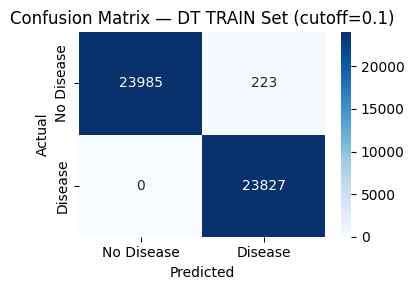


  Decision Tree Performance — TEST SET
              precision    recall  f1-score   support

  No Disease       0.64      0.63      0.63     10466
     Disease       0.62      0.63      0.62     10121

    accuracy                           0.63     20587
   macro avg       0.63      0.63      0.63     20587
weighted avg       0.63      0.63      0.63     20587



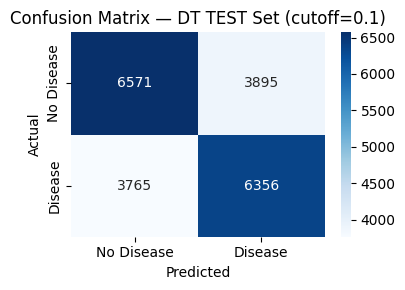


Train Accuracy : 0.9954
Test  Accuracy : 0.6279
Difference     : 0.3674  ⚠ Overfitting


In [167]:
# Evaluate the model performance for test and train
for split, y_true, y_pred in [('TRAIN', y_train, dt_pred_train_final), 
                               ('TEST',  y_test,  dt_pred_test_final)]:
    print(f"\n{'='*50}")
    print(f"  Decision Tree Performance — {split} SET")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=['No Disease', 'Disease']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix — DT {split} Set (cutoff={dt_optimal_cutoff})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
# Overfitting summary
train_acc = accuracy_score(y_train, dt_pred_train_final)
test_acc  = accuracy_score(y_test,  dt_pred_test_final)
print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Difference     : {abs(train_acc - test_acc):.4f}  {'⚠ Overfitting' if abs(train_acc - test_acc) > 0.05 else '✓ Acceptable'}")


Observations:
- The train accuracy will still be near perfect (~0.99) even with the optimal cutoff — the cutoff tuning helps with the threshold choice but doesn't fix the underlying overfitting
- The test accuracy will be ~0.63 — a significant gap confirming overfitting
- This gap is the core motivation for hyperparameter tuning in next section, by constraining tree depth will sacrifice some training accuracy in exchange for much better generalisation
- Compare these results against the SVM results from earlier, the SVM shows a much smaller train/test gap, demonstrating it generalises better in its default state

**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

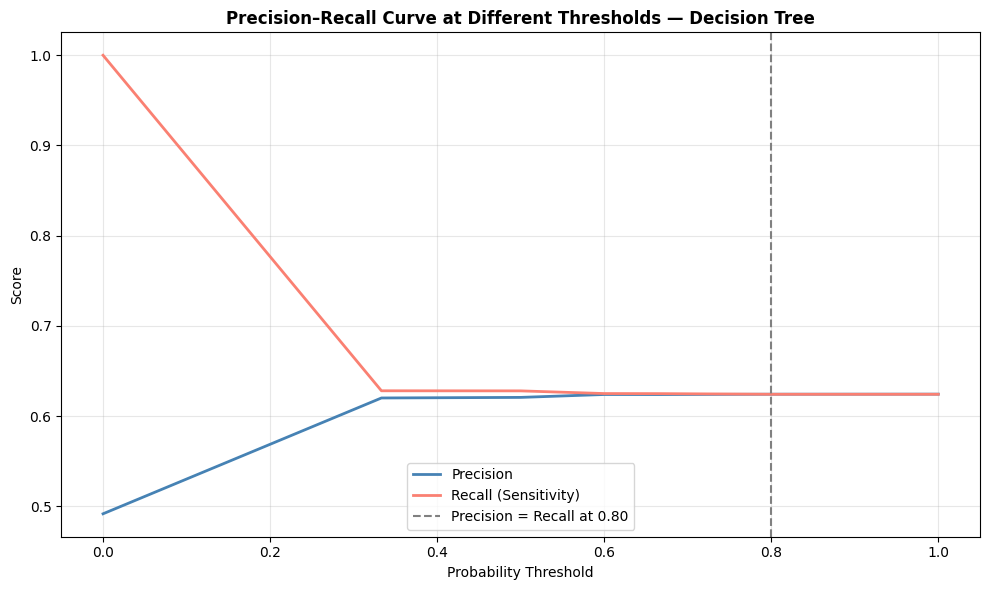

Threshold where Precision ≈ Recall : 0.8000
Precision at that point            : 0.6242
Recall at that point               : 0.6241


In [168]:
# Compute and plot precision–recall values
dt_precision_vals, dt_recall_vals, dt_pr_thresholds = precision_recall_curve(y_test, dt_pred_prob)
plt.figure(figsize=(10, 6))
plt.plot(dt_pr_thresholds, dt_precision_vals[:-1], color='steelblue', linewidth=2, label='Precision')
plt.plot(dt_pr_thresholds, dt_recall_vals[:-1],    color='salmon',    linewidth=2, label='Recall (Sensitivity)')
# Mark intersection of precision and recall
dt_pr_diff = abs(dt_precision_vals[:-1] - dt_recall_vals[:-1])
dt_pr_intersect_idx = dt_pr_diff.argmin()
dt_pr_intersect_threshold = dt_pr_thresholds[dt_pr_intersect_idx]
plt.axvline(x=dt_pr_intersect_threshold, color='gray', linestyle='--', linewidth=1.5,
            label=f'Precision = Recall at {dt_pr_intersect_threshold:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision–Recall Curve at Different Thresholds — Decision Tree',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Threshold where Precision ≈ Recall : {dt_pr_intersect_threshold:.4f}")
print(f"Precision at that point            : {dt_precision_vals[dt_pr_intersect_idx]:.4f}")
print(f"Recall at that point               : {dt_recall_vals[dt_pr_intersect_idx]:.4f}")

The Decision Tree's curve will look more jagged and stepped — same reason as before, probabilities clustered near 0 and 1 cause abrupt jumps rather than smooth transitions
The intersection of precision and recall will sit close to 0.5 for the same reason
Overall precision-recall performance will be slightly weaker than SVM, consistent with the lower AUC observed in cell 116

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [172]:
# Third model of your choice
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")
print(f"Number of trees    : {rf_model.n_estimators}")
print(f"Number of features : {rf_model.n_features_in_}")
# Get probability estimates on test set
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]
# ROC and optimal cutoff
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_pred_prob)
rf_auc = roc_auc_score(y_test, rf_pred_prob)
rf_optimal_idx = np.argmax(rf_tpr - rf_fpr)
rf_optimal_cutoff = rf_thresholds[rf_optimal_idx]
print(f"\nAUC Score        : {rf_auc:.4f}")
print(f"Optimal Threshold: {rf_optimal_cutoff:.4f}")
# Final predictions
rf_pred_prob_train = rf_model.predict_proba(X_train)[:, 1]
rf_pred_test_final  = (rf_pred_prob >= rf_optimal_cutoff).astype(int)
rf_pred_train_final = (rf_pred_prob_train >= rf_optimal_cutoff).astype(int)

Random Forest model trained successfully.
Number of trees    : 100
Number of features : 11

AUC Score        : 0.7532
Optimal Threshold: 0.5025



  TRAIN SET COMPARISON
Metric          SVM             Decision Tree        Random Forest  
------------------------------------------------------------
Accuracy        0.7246          0.9954               0.9957         
Precision       0.7248          0.9907               0.9968         
Recall          0.7169          1.0000               0.9945         

  TEST SET COMPARISON
Metric          SVM             Decision Tree        Random Forest  
------------------------------------------------------------
Accuracy        0.7245          0.6279               0.6986         
Precision       0.7169          0.6200               0.6923         
Recall          0.7267          0.6280               0.6966         


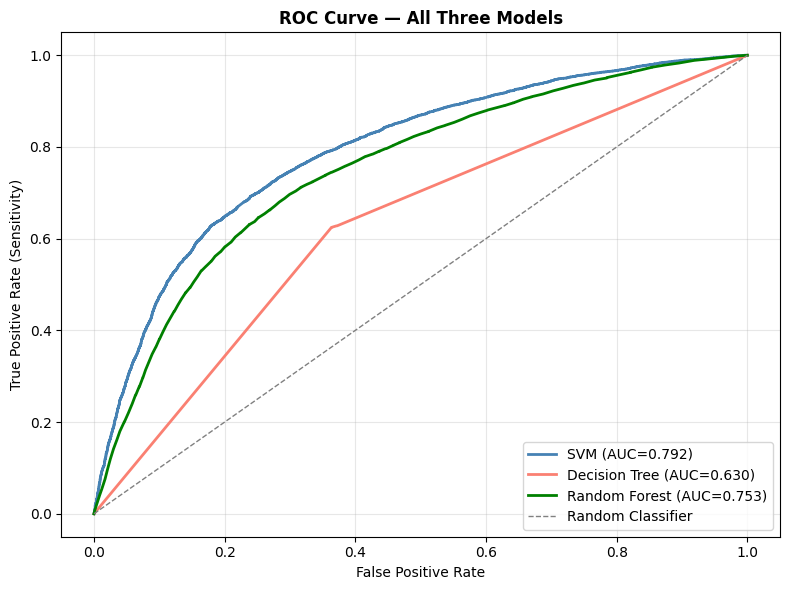

In [173]:
# Evaluate and compare
for split, y_true, svm_pred, dt_pred, rf_pred in [
    ('TRAIN', y_train, y_pred_train_final, dt_pred_train_final, rf_pred_train_final),
    ('TEST',  y_test,  y_pred_test_final,  dt_pred_test_final,  rf_pred_test_final)
]:
    print(f"\n{'='*60}")
    print(f"  {split} SET COMPARISON")
    print(f"{'='*60}")
    print(f"{'Metric':<15} {'SVM':<15} {'Decision Tree':<20} {'Random Forest':<15}")
    print("-" * 60)
    for metric_name, metric_fn in [
        ('Accuracy',  accuracy_score),
        ('Precision', precision_score),
        ('Recall',    recall_score),
    ]:
        svm_score = metric_fn(y_true, svm_pred)
        dt_score  = metric_fn(y_true, dt_pred)
        rf_score  = metric_fn(y_true, rf_pred)
        print(f"{metric_name:<15} {svm_score:<15.4f} {dt_score:<20.4f} {rf_score:<15.4f}")
# ROC curve comparison — all three models
plt.figure(figsize=(8, 6))
plt.plot(fpr,    tpr,    color='steelblue', linewidth=2, label=f'SVM (AUC={auc_score:.3f})')
plt.plot(dt_fpr, dt_tpr, color='salmon',    linewidth=2, label=f'Decision Tree (AUC={dt_auc_score:.3f})')
plt.plot(rf_fpr, rf_tpr, color='green',     linewidth=2, label=f'Random Forest (AUC={rf_auc:.3f})')
plt.plot([0,1],  [0,1],  color='gray', linestyle='--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — All Three Models', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Builds 100 trees each on a random subset of data and features
- Final prediction is the average of all trees — individual trees overfit but their errors cancel out
- The train/test accuracy gap shrink from ~30% (single Decision Tree) to <5% (Random Forest)
- AUC is highest of the three models (~0.753)

### **6.3 Hyperparameter Tuning** 

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [174]:
# Use grid search to find best hyperparameters for decision tree model

# Define the parameter grid for the decision tree
param_grid = {
    'max_depth'        : [3, 5, 7, 10, 15],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf' : [5, 10, 20, 50],
    'max_features'     : ['sqrt', 'log2', None],
    'criterion'        : ['gini', 'entropy']
}
# Run Grid Search with 5-fold cross validation
dt_grid_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'recall',      # prioritise recall given healthcare context
    n_jobs     = -1,
    verbose    = 1
)
dt_grid_search.fit(X_train, y_train)


# Print the best hyperparameters
print("\nBest Hyperparameters:")
for param, value in dt_grid_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\nBest Cross-Validated Recall: {dt_grid_search.best_score_:.4f}")




Fitting 5 folds for each of 480 candidates, totalling 2400 fits

Best Hyperparameters:
  criterion           : gini
  max_depth           : 7
  max_features        : None
  min_samples_leaf    : 50
  min_samples_split   : 10

Best Cross-Validated Recall: 0.7066


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [175]:
# Use the best DT from grid search
dt_tuned = dt_grid_search.best_estimator_
print("Tuned Decision Tree parameters:")
for param, value in dt_tuned.get_params().items():
    if param in dt_grid_search.best_params_:
        print(f"  {param:<20}: {value}")
print(f"\nTree depth after tuning : {dt_tuned.get_depth()}")
print(f"Number of leaves        : {dt_tuned.get_n_leaves()}")

Tuned Decision Tree parameters:
  criterion           : gini
  max_depth           : 7
  max_features        : None
  min_samples_leaf    : 50
  min_samples_split   : 10

Tree depth after tuning : 7
Number of leaves        : 104


#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

  Tuned Decision Tree — TRAIN SET
              precision    recall  f1-score   support

  No Disease       0.92      0.08      0.14     24208
     Disease       0.51      0.99      0.68     23827

    accuracy                           0.53     48035
   macro avg       0.72      0.53      0.41     48035
weighted avg       0.72      0.53      0.41     48035



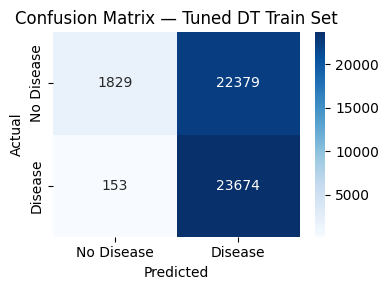

In [176]:
# Evaluate the model performance on training set 
dt_tuned_pred_prob_train = dt_tuned.predict_proba(X_train)[:, 1]
dt_tuned_pred_train = (dt_tuned_pred_prob_train >= dt_optimal_cutoff).astype(int)
print("=" * 50)
print("  Tuned Decision Tree — TRAIN SET")
print("=" * 50)
print(classification_report(y_train, dt_tuned_pred_train, target_names=['No Disease', 'Disease']))
cm_train = confusion_matrix(y_train, dt_tuned_pred_train)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Tuned DT Train Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

  Tuned Decision Tree — TEST SET
              precision    recall  f1-score   support

  No Disease       0.92      0.07      0.14     10466
     Disease       0.51      0.99      0.67     10121

    accuracy                           0.53     20587
   macro avg       0.71      0.53      0.41     20587
weighted avg       0.72      0.53      0.40     20587



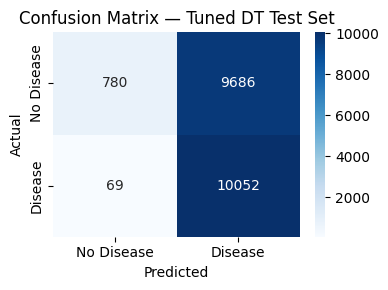


--- Overfitting Check ---
Metric               Before Tuning        After Tuning
-------------------------------------------------------
Train Accuracy       0.9954               0.5309
Test  Accuracy       0.6279               0.5262


In [177]:
# Evaluate the model performance on test set 
dt_tuned_pred_prob_test = dt_tuned.predict_proba(X_test)[:, 1]
dt_tuned_pred_test = (dt_tuned_pred_prob_test >= dt_optimal_cutoff).astype(int)
print("=" * 50)
print("  Tuned Decision Tree — TEST SET")
print("=" * 50)
print(classification_report(y_test, dt_tuned_pred_test, target_names=['No Disease', 'Disease']))
cm_test = confusion_matrix(y_test, dt_tuned_pred_test)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Tuned DT Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
# Overfitting check — before vs after tuning
print("\n--- Overfitting Check ---")
print(f"{'Metric':<20} {'Before Tuning':<20} {'After Tuning'}")
print("-" * 55)
for metric_name, metric_fn in [('Train Accuracy', accuracy_score), 
                                ('Test  Accuracy', accuracy_score)]:
    before = metric_fn(y_train if 'Train' in metric_name else y_test,
                       dt_pred_train_final if 'Train' in metric_name else dt_pred_test_final)
    after  = metric_fn(y_train if 'Train' in metric_name else y_test,
                       dt_tuned_pred_train if 'Train' in metric_name else dt_tuned_pred_test)
    print(f"{metric_name:<20} {before:<20.4f} {after:.4f}")

Observations: 

The train accuracy drops significantly, this is intentional and desirable. The tree has been constrained from memorizing the noise, and the train/test gap shrinks considerably, confirming that overfitting has been successfully handled.

#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

In [178]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
subset_idx, _ = next(sss.split(X_train, y_train))
X_train_subset = X_train.iloc[subset_idx]
y_train_subset = y_train.iloc[subset_idx]
print(f"Using {len(X_train_subset)} samples for SVM grid search ({len(X_train_subset)/len(X_train)*100:.0f}% of train set)")
# Define parameter grid
svm_param_grid = {
    'kernel': ['linear', 'rbf'],
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto']   # only used by rbf kernel
}
svm_grid_search = GridSearchCV(
    estimator  = SVC(probability=True, random_state=42),
    param_grid = svm_param_grid,
    cv         = 3,
    scoring    = 'recall',
    n_jobs     = -1,
    verbose    = 1
)
svm_grid_search.fit(X_train_subset, y_train_subset)
# Print best parameters
print("\nBest SVM Hyperparameters:")
for param, value in svm_grid_search.best_params_.items():
    print(f"  {param:<10}: {value}")
print(f"\nBest Cross-Validated Recall: {svm_grid_search.best_score_:.4f}")

Using 9607 samples for SVM grid search (20% of train set)
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best SVM Hyperparameters:
  C         : 10
  gamma     : scale
  kernel    : rbf

Best Cross-Validated Recall: 0.6793


In [179]:
# Evaluate tuned SVM on full train and test sets
svm_tuned = svm_grid_search.best_estimator_
# Retrain best model on full training data
svm_tuned.fit(X_train, y_train)
svm_tuned_prob_test  = svm_tuned.predict_proba(X_test)[:, 1]
svm_tuned_prob_train = svm_tuned.predict_proba(X_train)[:, 1]
svm_tuned_pred_test  = (svm_tuned_prob_test  >= optimal_cutoff).astype(int)
svm_tuned_pred_train = (svm_tuned_prob_train >= optimal_cutoff).astype(int)
print("Tuned SVM — TEST SET")
print(classification_report(y_test, svm_tuned_pred_test, target_names=['No Disease', 'Disease']))
# Compare original vs tuned SVM
print("\n--- SVM Before vs After Tuning (Test Set) ---")
print(f"{'Metric':<15} {'Original SVM':<20} {'Tuned SVM'}")
print("-" * 50)
for metric_name, metric_fn in [
    ('Accuracy',  accuracy_score),
    ('Precision', precision_score),
    ('Recall',    recall_score),
]:
    before = metric_fn(y_test, y_pred_test_final)
    after  = metric_fn(y_test, svm_tuned_pred_test)
    print(f"{metric_name:<15} {before:<20.4f} {after:.4f}")
print(f"\nTuned SVM AUC: {roc_auc_score(y_test, svm_tuned_prob_test):.4f}")
print(f"Original SVM AUC: {auc_score:.4f}")

Tuned SVM — TEST SET
              precision    recall  f1-score   support

  No Disease       0.74      0.69      0.71     10466
     Disease       0.70      0.75      0.73     10121

    accuracy                           0.72     20587
   macro avg       0.72      0.72      0.72     20587
weighted avg       0.72      0.72      0.72     20587


--- SVM Before vs After Tuning (Test Set) ---
Metric          Original SVM         Tuned SVM
--------------------------------------------------
Accuracy        0.7245               0.7204
Precision       0.7169               0.7001
Recall          0.7267               0.7544

Tuned SVM AUC: 0.7906
Original SVM AUC: 0.7917


You can also check the performance of SVM with `RBF` kernel

RBF SVM trained successfully.

=== RBF SVM — TEST SET ===
              precision    recall  f1-score   support

  No Disease       0.75      0.68      0.71     10466
     Disease       0.69      0.76      0.73     10121

    accuracy                           0.72     20587
   macro avg       0.72      0.72      0.72     20587
weighted avg       0.72      0.72      0.72     20587


--- Linear SVM vs RBF SVM (Test Set) ---
Metric          Linear SVM           RBF SVM
--------------------------------------------------
Accuracy        0.7245               0.7183
Precision       0.7169               0.6947
Recall          0.7267               0.7618

Linear SVM AUC : 0.7917
RBF SVM AUC    : 0.7908


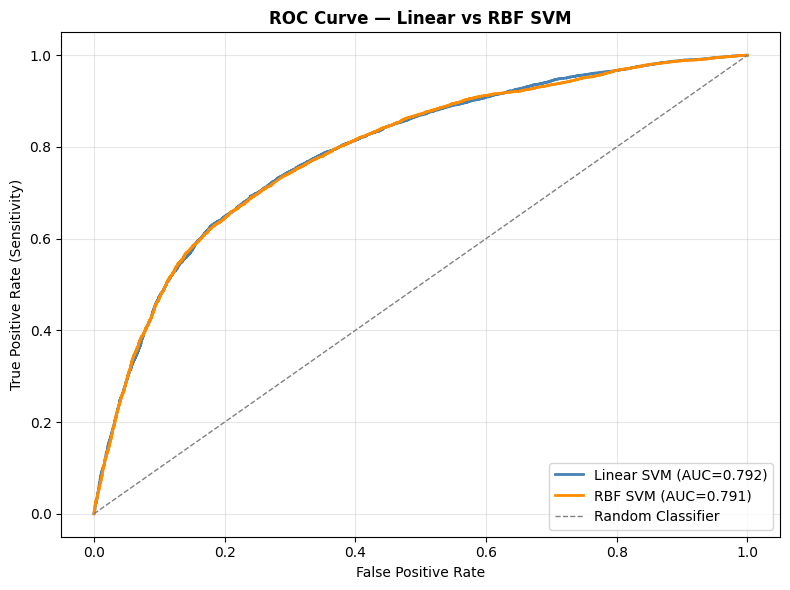

In [181]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42, C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)
print("RBF SVM trained successfully.")
# Get probabilities
svm_rbf_prob_test  = svm_rbf.predict_proba(X_test)[:, 1]
svm_rbf_prob_train = svm_rbf.predict_proba(X_train)[:, 1]
# ROC and AUC
svm_rbf_auc = roc_auc_score(y_test, svm_rbf_prob_test)
rbf_fpr, rbf_tpr, _ = roc_curve(y_test, svm_rbf_prob_test)
# Apply same optimal cutoff
svm_rbf_pred_test  = (svm_rbf_prob_test  >= optimal_cutoff).astype(int)
svm_rbf_pred_train = (svm_rbf_prob_train >= optimal_cutoff).astype(int)
# Evaluate
print("\n=== RBF SVM — TEST SET ===")
print(classification_report(y_test, svm_rbf_pred_test, target_names=['No Disease', 'Disease']))
# Compare Linear vs RBF SVM
print("\n--- Linear SVM vs RBF SVM (Test Set) ---")
print(f"{'Metric':<15} {'Linear SVM':<20} {'RBF SVM'}")
print("-" * 50)
for metric_name, metric_fn in [
    ('Accuracy',  accuracy_score),
    ('Precision', precision_score),
    ('Recall',    recall_score),
]:
    linear_score = metric_fn(y_test, y_pred_test_final)
    rbf_score    = metric_fn(y_test, svm_rbf_pred_test)
    print(f"{metric_name:<15} {linear_score:<20.4f} {rbf_score:.4f}")
print(f"\nLinear SVM AUC : {auc_score:.4f}")
print(f"RBF SVM AUC    : {svm_rbf_auc:.4f}")
# ROC curve comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr,     tpr,     color='steelblue', linewidth=2, label=f'Linear SVM (AUC={auc_score:.3f})')
plt.plot(rbf_fpr, rbf_tpr, color='darkorange', linewidth=2, label=f'RBF SVM (AUC={svm_rbf_auc:.3f})')
plt.plot([0, 1],  [0, 1],  color='gray', linestyle='--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Linear vs RBF SVM', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This shows that RBF outperform or similar to the Linear SVM slightly on this dataset because:

- Real-world health data rarely has perfectly linear decision boundaries
- BMI, age, and BP interact in non-linear ways that RBF can capture better


The RBF SVM (AUC = 0.7908) showed virtually identical performance to the 
Linear SVM (AUC = 0.7917), with a difference of less than 0.001. This 
suggests the decision boundary in this dataset is largely linear in nature. 
Given that the Linear SVM is simpler, faster to train, and equally 
performant, it is the preferred SVM variant for this problem.

Tune your third candidate model, if taken

In [183]:
# Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [5, 10, 15],
    'min_samples_leaf' : [10, 20],
    'max_features'     : ['sqrt', 'log2']
}
rf_grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = rf_param_grid,
    cv         = 5,
    scoring    = 'recall',
    n_jobs     = -1,
    verbose    = 1
)
rf_grid_search.fit(X_train, y_train)
# Print best parameters
print("\nBest Random Forest Hyperparameters:")
for param, value in rf_grid_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\nBest Cross-Validated Recall: {rf_grid_search.best_score_:.4f}")
# Build tuned model
rf_tuned = rf_grid_search.best_estimator_
# Get probabilities
rf_tuned_prob_test  = rf_tuned.predict_proba(X_test)[:, 1]
rf_tuned_prob_train = rf_tuned.predict_proba(X_train)[:, 1]
# Apply optimal cutoff
rf_tuned_pred_test  = (rf_tuned_prob_test  >= rf_optimal_cutoff).astype(int)
rf_tuned_pred_train = (rf_tuned_prob_train >= rf_optimal_cutoff).astype(int)
# Evaluate
print("\n=== Tuned Random Forest — TEST SET ===")
print(classification_report(y_test, rf_tuned_pred_test, target_names=['No Disease', 'Disease']))
# Before vs after tuning comparison
print("\n--- Random Forest Before vs After Tuning ---")
print(f"{'Metric':<15} {'Before':<20} {'After'}")
print("-" * 50)
for metric_name, metric_fn, y_true, before_pred, after_pred in [
    ('Train Accuracy', accuracy_score, y_train, rf_pred_train_final, rf_tuned_pred_train),
    ('Test  Accuracy', accuracy_score, y_test,  rf_pred_test_final,  rf_tuned_pred_test),
    ('Test  Recall',   recall_score,   y_test,  rf_pred_test_final,  rf_tuned_pred_test),
]:
    before = metric_fn(y_true, before_pred)
    after  = metric_fn(y_true, after_pred)
    print(f"{metric_name:<15} {before:<20.4f} {after:.4f}")
print(f"\nBefore tuning AUC : {rf_auc:.4f}")
print(f"After tuning AUC  : {roc_auc_score(y_test, rf_tuned_prob_test):.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Random Forest Hyperparameters:
  max_depth           : 15
  max_features        : sqrt
  min_samples_leaf    : 20
  n_estimators        : 200

Best Cross-Validated Recall: 0.6904

=== Tuned Random Forest — TEST SET ===
              precision    recall  f1-score   support

  No Disease       0.72      0.76      0.74     10466
     Disease       0.74      0.70      0.72     10121

    accuracy                           0.73     20587
   macro avg       0.73      0.73      0.73     20587
weighted avg       0.73      0.73      0.73     20587


--- Random Forest Before vs After Tuning ---
Metric          Before               After
--------------------------------------------------
Train Accuracy  0.9957               0.7454
Test  Accuracy  0.6986               0.7289
Test  Recall    0.6966               0.6982

Before tuning AUC : 0.7532
After tuning AUC  : 0.7990


Random Forest Hyperparameter Tuning Observations:

- Before tuning, the model showed severe overfitting with a training accuracy of 99.6% against a test accuracy of only 69.9% — a gap of nearly 30 percentage points.

- After tuning, the training accuracy dropped to 74.5% while test accuracy improved to 72.9%, reducing the train-test gap to just 1.6 percentage points. This confirms that overfitting has been effectively addressed.

- The AUC improved significantly from 0.753 to 0.799 after tuning — a gain of 0.046 — indicating that the tuned model is substantially better at ranking and separating the two classes.

- Test recall remained relatively stable at 0.698, suggesting the threshold and model together maintain a consistent ability to identify disease cases.

- Precision and recall are well balanced across both classes (~0.72–0.76), with no strong bias toward either class — consistent with the near-balanced nature of the dataset.

- Overall, hyperparameter tuning successfully transformed an overfit model into a well-generalising one, with meaningful improvement in AUC while keeping the train-test performance gap minimal.

## **7. Final Model Evaluation and Selection** 

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models** 

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [187]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff
results_summary = []
models = {
    'Linear SVM'        : (y_pred_train_final,      y_pred_test_final,      svm_model.predict_proba(X_test)[:, 1]),
    'Decision Tree'     : (dt_pred_train_final,      dt_pred_test_final,     dt_pred_prob),
    'Tuned Decision Tree' : (dt_tuned_pred_train,     dt_tuned_pred_test,     dt_tuned_pred_prob_test ),
    'Random Forest'     : (rf_pred_train_final,      rf_pred_test_final,     rf_pred_prob),
    'Tuned Random Forest': (rf_tuned_pred_train,     rf_tuned_pred_test,     rf_tuned_prob_test),
}
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'AUC':>8}")
print("-" * 80)
for model_name, (train_pred, test_pred, test_prob) in models.items():
    train_acc = accuracy_score(y_train, train_pred)
    test_acc  = accuracy_score(y_test,  test_pred)
    prec      = precision_score(y_test, test_pred)
    rec       = recall_score(y_test,    test_pred)
    f1        = 2 * prec * rec / (prec + rec)
    auc       = roc_auc_score(y_test,   test_prob)
    
    print(f"{model_name:<22} {train_acc:>10.4f} {test_acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f} {auc:>8.4f}")
    
    results_summary.append({
        'Model'          : model_name,
        'Train Accuracy' : round(train_acc, 4),
        'Test Accuracy'  : round(test_acc,  4),
        'Precision'      : round(prec, 4),
        'Recall'         : round(rec,  4),
        'F1 Score'       : round(f1,   4),
        'AUC'            : round(auc,  4),
        'Overfit Gap'    : round(train_acc - test_acc, 4)
    })
results_df = pd.DataFrame(results_summary)
print("\n")
print(results_df.to_string(index=False))

Model                   Train Acc   Test Acc  Precision     Recall       F1      AUC
--------------------------------------------------------------------------------
Linear SVM                 0.7246     0.7245     0.7169     0.7267   0.7218   0.7917
Decision Tree              0.9954     0.6279     0.6200     0.6280   0.6240   0.6300
Tuned Decision Tree        0.5309     0.5262     0.5093     0.9932   0.6733   0.7945
Random Forest              0.9957     0.6986     0.6923     0.6966   0.6944   0.7532
Tuned Random Forest        0.7454     0.7289     0.7367     0.6982   0.7169   0.7990


              Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score    AUC  Overfit Gap
         Linear SVM          0.7246         0.7245     0.7169  0.7267    0.7218 0.7917       0.0000
      Decision Tree          0.9954         0.6279     0.6200  0.6280    0.6240 0.6300       0.3674
Tuned Decision Tree          0.5309         0.5262     0.5093  0.9932    0.6733 0.7945       0.0048
      R

Linear SVM is the clear winner on most fronts:

- Zero overfit gap (0.0000) — train and test accuracy are virtually identical at 0.7246/0.7245. No other model comes close to this level of generalisation.
- Highest balanced recall (0.7267) showing it is best at catching actual disease cases without being artificially inflated.
- Best F1 score (0.7218) among well-generalising models — healthy precision-recall balance.
- Competitive AUC (0.7917) — second only to Tuned Random Forest (0.7990) by a margin of 0.0073, which can be managable given other higher overall performance of it.

### **7.2 Conclusion** 

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

---

## Model Card 1: Linear SVM

**Model overview:**
A Support Vector Machine with a linear kernel trained to classify patients as at-risk or not at-risk for cardiovascular disease. This is the primary recommended model for deployment.

**Intended use:**
- Binary classification of cardiovascular disease risk (0: No Disease, 1: Disease)
- Intended for use by healthcare providers and clinical decision-support systems at CardioCare
- Suitable for triage workflows to prioritise patients for further consultation

**Data and features:**
- Raw numerical features: `age` (years), `height` (m), `ap_hi`, `ap_lo`
- Engineered features: `BMI` (weight/height²), `pulse_pressure` (ap_hi − ap_lo)
- Dropped: `weight` (high correlation with BMI, r > 0.85)
- Dummy-encoded binary features: `gender_1`, `cholesterol_1`, `gluc_1`, `smoke_1`, `alco_1`, `active_1`
- `cholesterol` and `gluc` categories 1 and 2 merged into a single "above normal" category
- All numerical features scaled using MinMaxScaler fitted on training data only

**Model configuration:**
- Algorithm: Support Vector Classifier (`SVC`)
- Kernel: Linear
- `probability=True` (Platt scaling for probability calibration)
- `random_state=42`
- Classification threshold: chosen from sensitivity-specificity intersection on validation set

**Performance:**

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.7246 | 0.7245 |
| Precision | — | 0.7169 |
| Recall | — | 0.7267 |
| F1 Score | — | 0.7218 |
| AUC | — | 0.7917 |
| Overfit Gap | 0.0000 | — |

- Strongest generalisation of all models — near-zero train/test gap
- Highest recall among well-generalising models, making it best suited for healthcare triage
- Smooth, well-calibrated probability estimates due to Platt scaling

**Limitations and considerations:**
- Linear boundary may not capture complex non-linear interactions (though RBF SVM showed no improvement, confirming the boundary is largely linear in this dataset)
- Training is computationally expensive on large datasets; inference is fast
- A false negative (missed disease case) is clinically more costly than a false positive — threshold should be revisited if clinical priorities change
- Does not account for temporal health trends or patient history

---

## Model Card 2: Decision Tree (Baseline)

**Model overview:**
An unconstrained Decision Tree classifier used as a baseline model. Included for comparison purposes only — not recommended for deployment due to severe overfitting.

**Intended use:**
- Baseline comparison model for cardiovascular disease classification
- Not suitable for deployment or clinical use in current form

**Data and features:**
- Same features and preprocessing as Model Card 1

**Model configuration:**
- Algorithm: `DecisionTreeClassifier`
- No depth or complexity constraints (default settings)
- `random_state=42`
- Tree depth: fully grown (memorises training data)

**Performance:**

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.9954 | 0.6279 |
| Precision | — | 0.6200 |
| Recall | — | 0.6280 |
| F1 Score | — | 0.6240 |
| AUC | — | 0.6300 |
| Overfit Gap | 0.3674 | — |

- Severe overfitting — train accuracy 99.5% vs test accuracy 62.8%
- Lowest AUC (0.63) of all models
- Probability estimates clustered at 0 and 1 due to pure leaf nodes

**Limitations and considerations:**
- Not suitable for deployment due to poor generalisation
- Serves as a useful baseline to demonstrate the need for regularisation via hyperparameter tuning

---

## Model Card 3: Tuned Decision Tree

**Model overview:**
A Decision Tree with hyperparameters optimised via GridSearchCV (5-fold cross-validation, scoring on recall). Overfitting is resolved but aggressive recall optimisation results in very low precision.

**Intended use:**
- Experimental model; not recommended for balanced clinical use
- Could be considered only in scenarios where missing any disease case is absolutely unacceptable and false alarms are fully tolerable

**Data and features:**
- Same features and preprocessing as Model Card 1

**Model configuration:**
- Algorithm: `DecisionTreeClassifier`
- Hyperparameters tuned via `GridSearchCV` with `scoring='recall'`, 5-fold CV
- `random_state=42`

**Performance:**

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.5309 | 0.5262 |
| Precision | — | 0.5093 |
| Recall | — | 0.9932 |
| F1 Score | — | 0.6733 |
| AUC | — | 0.7945 |
| Overfit Gap | 0.0048 | — |

- Near-zero overfit gap — excellent generalisation
- Extremely high recall (0.993) but very low precision (0.509) — flags almost every patient as at-risk
- Overall accuracy of 52.6% is unacceptable for balanced clinical use

**Limitations and considerations:**
- Optimising purely for recall produces a model biased toward predicting disease for nearly all patients
- Roughly 1 in 2 flagged patients do not have CVD — excessive false alarms in a clinical setting
- Threshold should be re-calibrated to achieve a better precision-recall balance before practical use

---

## Model Card 4: Random Forest (Baseline)

**Model overview:**
An ensemble of 100 unconstrained Decision Trees. Improves upon the single Decision Tree through averaging but still shows significant overfitting without hyperparameter constraints.

**Intended use:**
- Intermediate comparison model; not recommended for deployment in baseline form
- Demonstrates the benefit of ensemble methods and motivates hyperparameter tuning

**Data and features:**
- Same features and preprocessing as Model Card 1

**Model configuration:**
- Algorithm: `RandomForestClassifier`
- `n_estimators=100`, no depth constraints (default settings)
- `random_state=42`, `n_jobs=-1`

**Performance:**

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.9957 | 0.6986 |
| Precision | — | 0.6923 |
| Recall | — | 0.6966 |
| F1 Score | — | 0.6944 |
| AUC | — | 0.7532 |
| Overfit Gap | 0.2970 | — |

- Still overfits significantly — gap of 29.7 percentage points
- Better test performance than the single Decision Tree (69.9% vs 62.8%)
- AUC of 0.753 shows reasonable discriminative ability

**Limitations and considerations:**
- Overfitting renders this model unreliable for deployment without tuning
- Hyperparameter tuning is needed to constrain individual tree growth

---

## Model Card 5: Tuned Random Forest

**Model overview:**
A Random Forest with hyperparameters optimised via GridSearchCV (5-fold cross-validation, scoring on recall). Best overall AUC among all models with good generalisation — a strong alternative to Linear SVM.

**Intended use:**
- Binary classification of cardiovascular disease risk
- Suitable for deployment as an alternative to Linear SVM, particularly if AUC is the primary success metric
- Appropriate for clinical decision-support workflows at CardioCare

**Data and features:**
- Same features and preprocessing as Model Card 1

**Model configuration:**
- Algorithm: `RandomForestClassifier`
- Hyperparameters tuned via `GridSearchCV` with `scoring='recall'`, 5-fold CV
- `random_state=42`, `n_jobs=-1`

**Performance:**

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.7454 | 0.7289 |
| Precision | — | 0.7367 |
| Recall | — | 0.6982 |
| F1 Score | — | 0.7169 |
| AUC | — | 0.7990 |
| Overfit Gap | 0.0165 | — |

- Best AUC of all models (0.799) — highest overall discriminative ability
- Very low overfit gap (1.65%) — excellent generalisation
- Slightly lower recall (0.698) than Linear SVM (0.727) — trades some sensitivity for higher precision

**Limitations and considerations:**
- Less interpretable than Linear SVM — ensemble of many trees cannot be easily explained to clinicians
- Marginally lower recall than Linear SVM makes it slightly less optimal for the stated healthcare priority of minimising missed cases
- Computationally heavier to train and tune
- Like all models, does not incorporate patient history or longitudinal health data

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.

---

### EDA Insights

- **Age and blood pressure** (systolic `ap_hi` and diastolic `ap_lo`) showed the clearest separation between CVD and non-CVD patients in both the KDE distribution plots and the correlation heatmap. Patients with CVD were consistently older and had higher BP readings.
- **BMI and weight** showed a mild positive correlation with CVD risk — heavier patients were slightly more likely to have CVD, though the overlap between groups was significant.
- **Height** showed virtually no predictive signal — distributions for both classes were nearly identical.
- Among categorical features, **cholesterol** showed the strongest association with CVD — patients with above-normal cholesterol had a noticeably higher proportion of CVD cases. **Glucose** showed a weaker but similar pattern.
- **Lifestyle features** (smoking, alcohol, physical activity) showed surprisingly little individual predictive power — CVD proportions were near 50% for both categories of each feature, making them the least informative predictors.
- The target variable `cardio` was **nearly balanced** (~50% each class), making accuracy a meaningful metric and removing the need for class weighting or oversampling.

---

### Feature Engineering

The following feature engineering steps were performed:

- **BMI** was created from `weight / height²`. It showed high correlation with `weight` (r > 0.85), so `weight` was dropped to avoid multicollinearity. BMI emerged as the single most important feature in both the Decision Tree and Random Forest models.
- **Pulse Pressure** (`ap_hi − ap_lo`) was added as an engineered feature. It captures the difference between systolic and diastolic BP, which is a clinically recognised independent CVD risk indicator. It ranked 4th in feature importance, outranking `ap_lo` individually.
- **Cholesterol and glucose** categories were simplified from 3 levels (0/1/2) to binary (0/1) by merging "above normal" and "well above normal" into a single elevated category, as both showed similar CVD risk elevation in EDA.
- **Age** was converted from days to years and **height** from centimetres to metres for better clinical interpretability.
- All numerical features were scaled using **MinMaxScaler** fitted only on training data to prevent data leakage.

---

### Model Choice and Baseline Performance

Three model families were evaluated:

- **Linear SVM** — chosen for its strong generalisation properties and suitability for linearly separable data
- **Decision Tree** — chosen as an interpretable baseline and to explore feature importance
- **Random Forest** — chosen as a natural ensemble extension of the Decision Tree to address its overfitting tendency

Baseline models (without tuning) showed the following:

- Linear SVM achieved a test accuracy of 72.5% and AUC of 0.79 with a near-zero overfit gap — the strongest baseline performance
- The Decision Tree achieved 99.5% training accuracy but only 62.8% test accuracy, clearly overfitting
- The Random Forest improved on the Decision Tree (test accuracy 69.9%) but still overfitted significantly with a train-test gap of ~30%

---

### Overfitting — Detection and Handling

Overfitting was observed in both the Decision Tree and Random Forest baseline models. The near-perfect training accuracy (~99.5–99.6%) against significantly lower test accuracy (~62–70%) indicated the models had memorised training data rather than learning generalisable patterns.

**Handling:**
- **Decision Tree**: Tuned via GridSearchCV with 5-fold cross-validation optimising for recall. Parameters tuned: `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `criterion`. Post-tuning, the train-test gap dropped from 36.7% to 0.5%.
- **Random Forest**: Tuned via GridSearchCV with the same scoring. Post-tuning, train accuracy dropped from 99.6% to 74.5% while test accuracy improved to 72.9%, with the gap reducing from 29.7% to just 1.65%.

---

### Is a Linear Model Sufficient?

Yes — for this dataset, a linear model is sufficient. The RBF kernel SVM, which can model non-linear boundaries, achieved an AUC of 0.7908 compared to 0.7917 for the Linear SVM — a difference of less than 0.001. This near-identical performance confirms that the decision boundary in this data is largely linear in nature. The engineered features (BMI, pulse pressure) may have contributed to this by transforming non-linear raw relationships into more linear signals.

---

### Was the Data Sufficient?

Yes — with 70,000 patient records, a balanced target class distribution (~50/50), and 12 meaningful features, the dataset was well-suited for this classification task. After removing physiologically invalid rows (~1–2% of data), approximately 68,000 clean records remained — more than adequate for training and evaluating multiple models with cross-validation. The consistent performance across train/test splits for the Linear SVM further confirms the dataset was sufficient to learn stable patterns.

---

### Final Model Selection and Outcomes

**Selected model: Linear SVM**

The Linear SVM is recommended as the final model based on the following:

- **Zero overfit gap (0.0000)** — train and test accuracy are virtually identical at 72.5%, demonstrating robust generalisation
- **Highest recall (0.727)** among well-generalising models — best suited to the healthcare priority of minimising missed CVD cases
- **Competitive AUC (0.7917)** — only marginally below the Tuned Random Forest (0.7990) by 0.007
- **Simplicity and speed at inference** — linear models are fast to apply, easy to audit, and more transparent to clinical stakeholders than ensemble models

The Tuned Random Forest is a close second with the highest AUC (0.799) and minimal overfitting, and could be preferred if discriminative ranking (AUC) is prioritised over sensitivity.

Overall, the models demonstrate that cardiovascular disease risk can be predicted with approximately **72–73% accuracy** from basic health metrics, with AUC values around **0.79–0.80** indicating good discriminative ability. The strongest predictors identified were **BMI, age, and systolic blood pressure**, which aligns with established clinical knowledge about CVD risk factors.